<a href="https://colab.research.google.com/github/Kaori-Sensei/Data-Analysis/blob/main/Taller_1_AE_Luis_Castillo_Datos_Monilia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Taller 1 Modelos_ ANÁLISIS DE DATOS**

Luis Alberto Castillo Sanabria

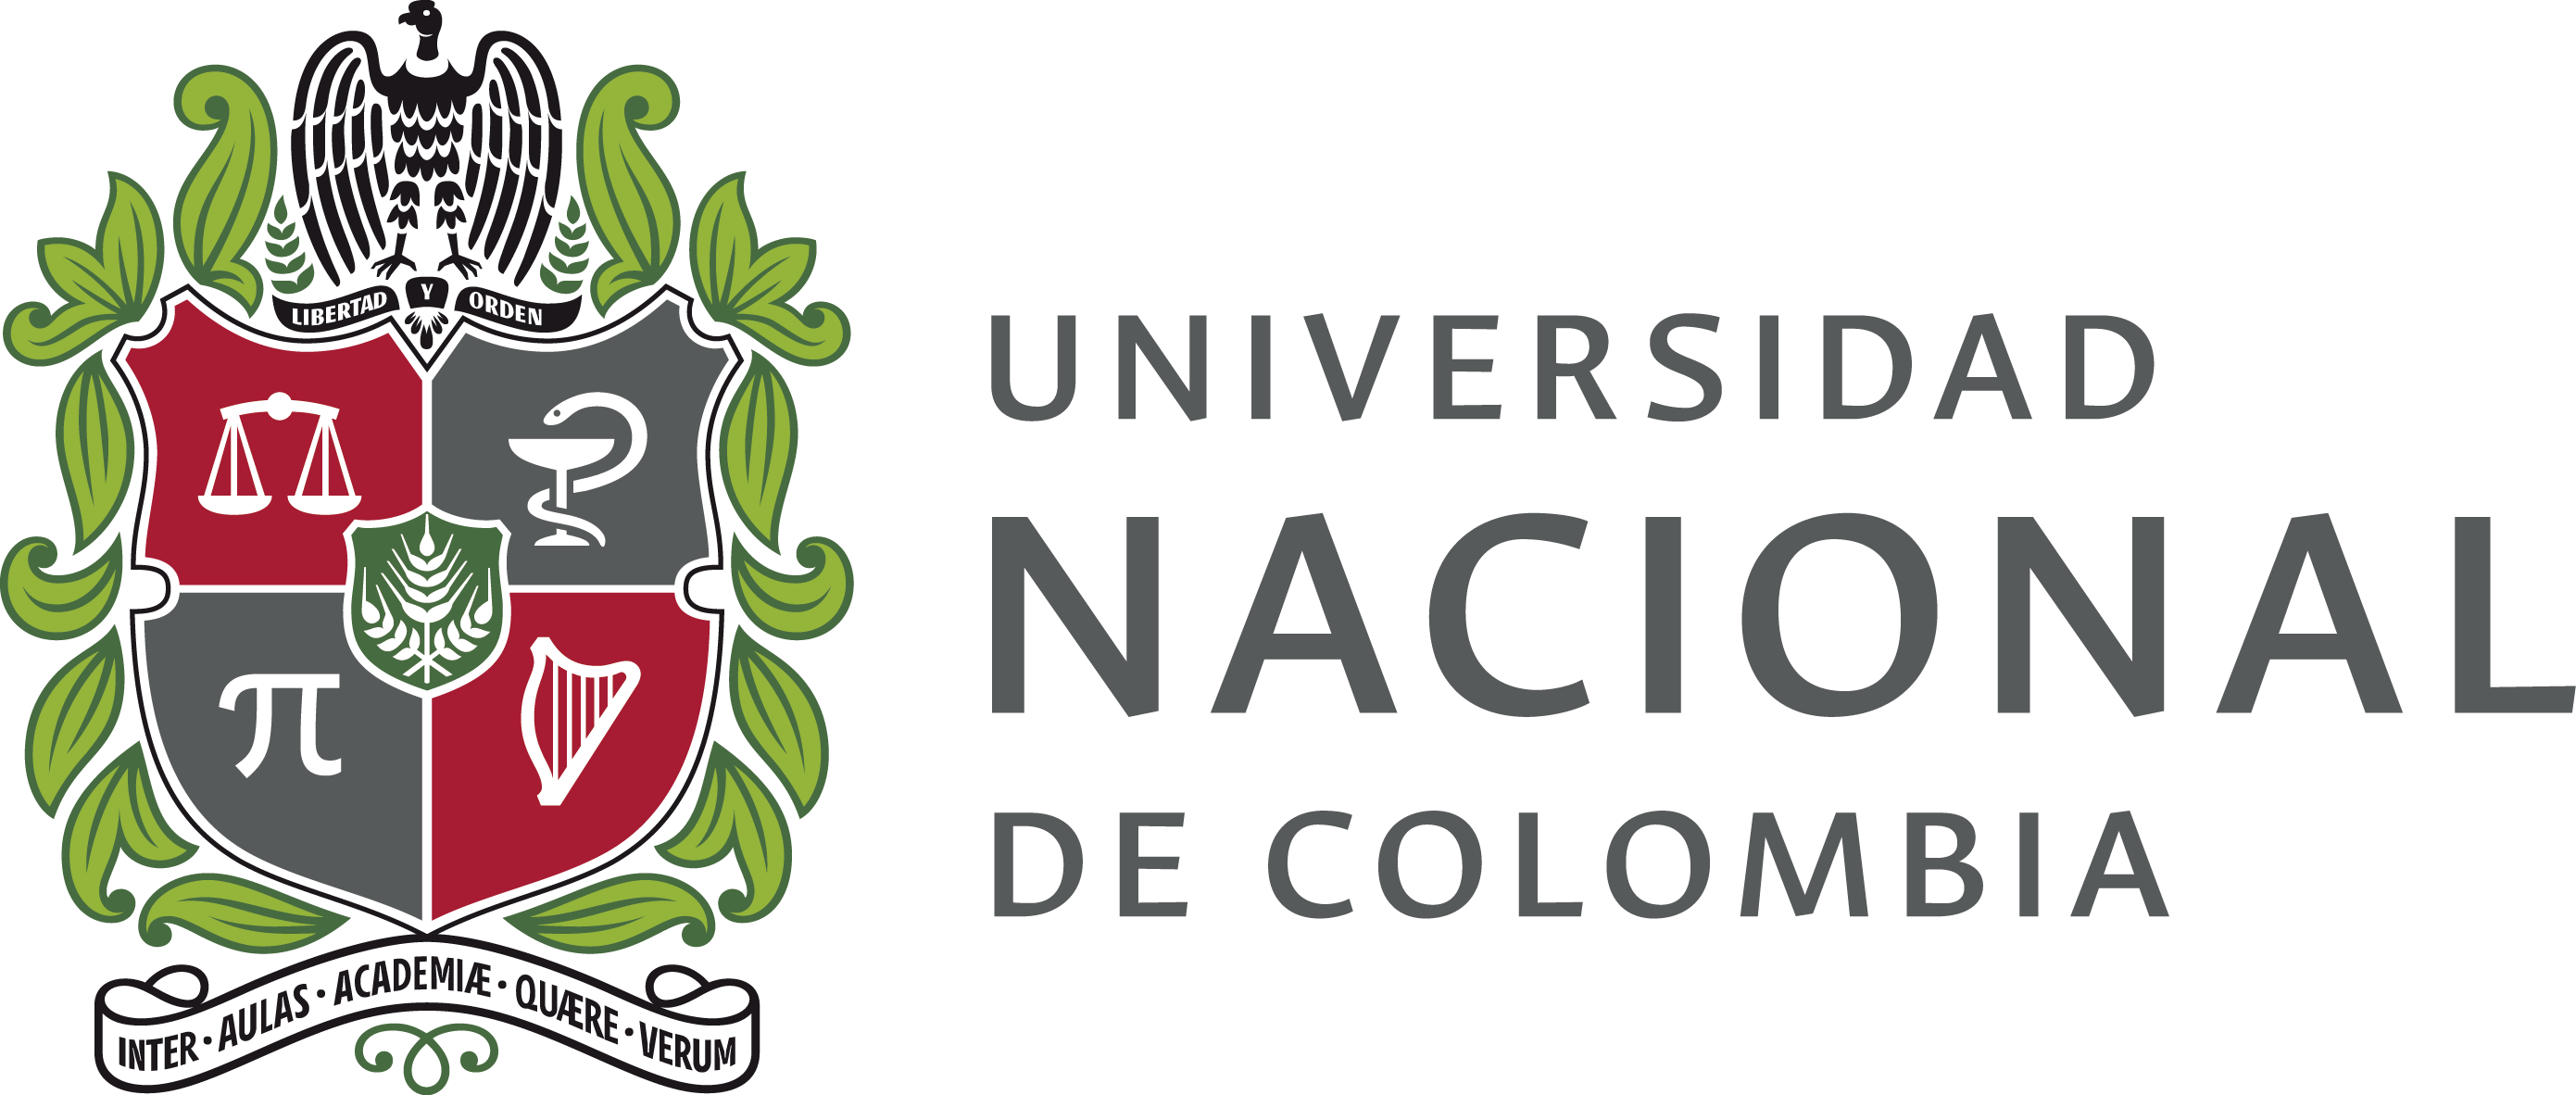


In [ ]:
# ============================================================
#  PIPELINE BÁSICO DE ANÁLISIS DE DATOS (Fitosanitario) – COLAB
#  1) Gestión de datos (limpieza, atípicos, faltantes, concat, ID)
#  2) Ampliación (derivadas + clima NASA POWER/ERA5/CHIRPS; fallback offline)
#  3) Visualización + selección de variables (redundancia, clusters)
#  4) Modelación temporal, espacial y espacio–temporal (freq., Bayes, ML)
#  Nota: listo para que pegues tu CSV de vigilancia fitosanitaria.
# ============================================================

# ---------- 0) SETUP ----------
!pip -q install pandas numpy matplotlib seaborn scikit-learn plotly statsmodels requests pymc --quiet

import os, io, json, math, warnings, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import plotly.express as px
import plotly.graph_objects as go
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
import requests

warnings.filterwarnings("ignore")
plt.style.use("ggplot")
sns.set_palette("viridis")
np.set_printoptions(suppress=True)

Introducción al Notebook: Pipeline Básico de Análisis de Datos Fitosanitarios
Este notebook tiene como objetivo principal ofrecer una pipeline completa para el análisis de datos de vigilancia fitosanitaria. A través de este proceso, se busca proporcionar herramientas y metodologías para la gestión, enriquecimiento, visualización y modelación de datos, permitiendo una comprensión profunda de la dinámica de las enfermedades y plagas.

La estructura del notebook se divide en las siguientes etapas:

1. Gestión de Datos: Incluye la limpieza de datos, manejo de valores atípicos y faltantes, concatenación y creación de identificadores únicos.

2. Ampliación de Datos: Se enfoca en la derivación de nuevas variables y la integración de datos climáticos (NASA POWER/ERA5/CHIRPS), con opciones de fallback offline.

3. Visualización y Selección de Variables: Presentación gráfica de los datos para identificar redundancias y agrupar variables (clusters), facilitando la selección de las más relevantes.

4. Modelación: Aplicación de técnicas de modelado temporal, espacial y espacio-temporal, utilizando enfoques frecuentistas, Bayesianos y de Machine Learning.

In [ ]:
# ---------- 1) UTILIDADES DE GESTIÓN DE DATOS ----------

#Convierte fecha a tipo datatime para pandas
def to_datetime_safe(s, utc=False):
    return pd.to_datetime(s, errors="coerce", utc=utc)
#Calcula distancia entre dos puntos
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1,lon1,lat2,lon2 = map(np.radians, [lat1,lon1,lat2,lon2])
    dlat = lat2-lat1; dlon = lon2-lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2*R*np.arcsin(np.sqrt(a))
#Elimina outliers --> En este caso iqr_filter(df, cols=["severidad_pct", "incidencia_pct"])
def iqr_filter(df, cols, k=1.5):
    mask = pd.Series(True, index=df.index)
    for c in cols:
        x = pd.to_numeric(df[c], errors="coerce")
        q1, q3 = x.quantile(0.25), x.quantile(0.75)
        iqr = q3-q1
        low, high = q1 - k*iqr, q3 + k*iqr
        mask &= (x >= low) & (x <= high) | x.isna()
    return df[mask].copy()

#Resumen de los datos faltantes
def missing_summary(df):
    ms = df.isnull().mean().sort_values(ascending=False)
    return ms[ms>0]

#Revision coordenadas
def coerce_coords(df, lat_col="lat", lon_col="lon"):
    df[lat_col] = pd.to_numeric(df[lat_col], errors="coerce")
    df[lon_col] = pd.to_numeric(df[lon_col], errors="coerce")
    # filtrar coordenadas inválidas
    m = df[lat_col].between(-90,90) & df[lon_col].between(-180,180)
    return df[m].copy()

#ID unico por fecha y coordenadas
def build_id(df, date_col="fecha", lat_col="lat", lon_col="lon", id_col="id_monitoreo"):
    # ID único por fecha (AAAAmmdd) + geohash simple (lat/lon redondeadas)
    dcode = pd.to_datetime(df[date_col]).dt.strftime("%Y%m%d").fillna("00000000")
    gcode = df[lat_col].round(3).astype(str) + "_" + df[lon_col].round(3).astype(str)
    df[id_col] = dcode + "_" + gcode
    return df

#Juntar varios archivos en un solo data frame (util para datos en archivos separados)
def concat_csv_folder(folder="/content/data", pattern=".csv"):
    frames = []
    if os.path.isdir(folder):
        for fn in os.listdir(folder):
            if fn.lower().endswith(pattern):
                frames.append(pd.read_csv(os.path.join(folder, fn)))
    return pd.concat(frames, ignore_index=True) if frames else None

#Matriz de pesos espaciales (W) y distancias (D)
def knn_weights_from_coords(coords_df, k=4, lat_col="lat", lon_col="lon"):
    """Devuelve matriz W fila-estandarizada y matriz de distancias D."""
    pts = coords_df[[lat_col,lon_col]].to_numpy()
    n = len(pts)
    D = np.zeros((n,n))
    for i in range(n):
        D[i] = haversine_km(pts[i,0], pts[i,1], pts[:,0], pts[:,1])
    W = np.zeros_like(D)
    for i in range(n):
        nn = np.argsort(D[i])[:k+1]
        nn = [j for j in nn if j!=i][:k]
        if nn: W[i, nn] = 1.0
    row = W.sum(axis=1, keepdims=True); row[row==0]=1.0
    W = W/row
    return W, D

Esta celda agrupa una serie de funciones de utilidad diseñadas para facilitar las etapas iniciales y fundamentales de cualquier pipeline de análisis de datos: la carga, limpieza, transformación y preparación de datos. Estas funciones son esenciales para asegurar la calidad y el formato adecuado de los datos antes de proceder con análisis más complejos o la modelación. Permiten manejar aspectos como la conversión de tipos de datos, la gestión de valores atípicos y faltantes, la estandarización de coordenadas geográficas, la creación de identificadores únicos y la consolidación de múltiples fuentes de datos.

In [ ]:
# ---------- 2) CARGA BASE FITOSANITARIA ---------
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd

Mounted at /content/drive


In [ ]:
ruta = "/content/monilia_mensual_por_lote_2019_2024.xlsx"
df = pd.read_excel(ruta)
df.head()

,fecha,departamento,municipio,cultivo,enfermedad,lote_id,lat_lote,lon_lote,incidencia_pct,severidad_pct,mes
0,2019-01-01,Santander,El Carmen de Chucurí,Cacao,Monilia del cacao (Moniliophthora roreri),Lote_ElCarmendeChucuri_01,6.681533,-73.4856,22.9,7.7,1
1,2019-02-01,Santander,El Carmen de Chucurí,Cacao,Monilia del cacao (Moniliophthora roreri),Lote_ElCarmendeChucuri_01,6.681533,-73.4856,19.0,10.7,2
2,2019-03-01,Santander,El Carmen de Chucurí,Cacao,Monilia del cacao (Moniliophthora roreri),Lote_ElCarmendeChucuri_01,6.681533,-73.4856,26.7,8.4,3
3,2019-04-01,Santander,El Carmen de Chucurí,Cacao,Monilia del cacao (Moniliophthora roreri),Lote_ElCarmendeChucuri_01,6.681533,-73.4856,28.1,12.9,4
4,2019-05-01,Santander,El Carmen de Chucurí,Cacao,Monilia del cacao (Moniliophthora roreri),Lote_ElCarmendeChucuri_01,6.681533,-73.4856,29.4,11.7,5


In [ ]:
#Número de filas
num_filas = df.shape[0]

#Número de columnas
num_columnas = df.shape[1]

print("Número de filas:", num_filas)
print("Número de columnas:", num_columnas)

Número de filas: 3240
Número de columnas: 11


In [ ]:
# ---------- 3) GESTIÓN DE DATOS (limpieza integral) ----------
# 3.1 tipos, fechas, coords válidas
# The original DataFrame 'df' already contains a 'fecha' column.
# The columns 'Year' and 'Week' were not found in 'df', causing a KeyError.
# Therefore, the line attempting to create 'fecha' from 'Year' and 'Week' is removed.
# The 'fecha' column from the original DataFrame is now processed directly.
df["fecha"] = to_datetime_safe(df["fecha"])
df = df.dropna(subset=["fecha"])
# The original DataFrame 'df' contains 'lat_lote' and 'lon_lote' columns for coordinates,
# instead of 'Latitude' and 'Longitude'. These are used in the coerce_coords function.
df = coerce_coords(df, "lat_lote","lon_lote")
df = df.drop_duplicates()

In [ ]:
# 3.2 ID por fecha+coord (redondeo 3 decimales)
df = build_id(df, date_col="fecha", lat_col="lat_lote", lon_col="lon_lote", id_col="id_mon")
# 3.3 Resumen de faltantes
print("\nFaltantes (proporción >0):\n", missing_summary(df))


Faltantes (proporción >0):
 Series([], dtype: float64)


In [ ]:
# 3.5 Detección/eliminación de atípicos univariados (IQR) — configurable
df_clean = iqr_filter(df, cols=["incidencia_pct","severidad_pct"], k=2.0)
print("Después de IQR:", df_clean.shape)

Después de IQR: (3240, 12)


In [ ]:
#Exploracion datos incidencia y severidad
df_clean[["incidencia_pct", "severidad_pct"]].describe()

,incidencia_pct,severidad_pct
count,3240.000000,3240.000000
mean,24.141389,10.077407
std,6.061509,3.278760
min,3.900000,0.000000
25%,19.900000,7.900000
50%,24.300000,10.100000
75%,28.500000,12.400000
max,43.300000,20.100000


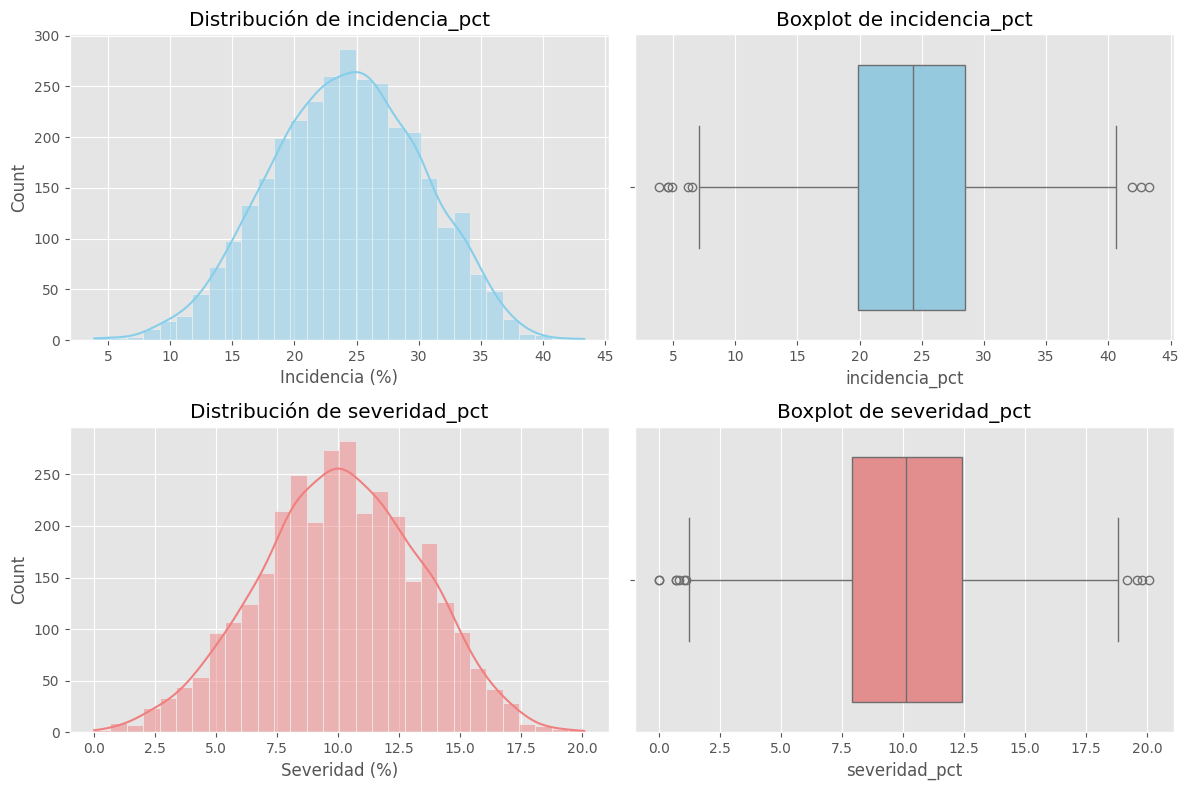

In [ ]:
#Exploracion y distribucion de incidencia y severidad
import matplotlib.pyplot as plt
import seaborn as sns

# Variables de interés
vars = [("incidencia_pct", "Incidencia (%)", "skyblue"),
        ("severidad_pct", "Severidad (%)", "lightcoral")]

# Crear figura: 2 filas × 2 columnas
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))

for i, (col, label, color) in enumerate(vars):
    # Histograma (columna 0)
    sns.histplot(df_clean[col], kde=True, bins=30, color=color, ax=axes[i,0])
    axes[i,0].set_title(f"Distribución de {col}")
    axes[i,0].set_xlabel(label)

    # Boxplot (columna 1)
    sns.boxplot(x=df_clean[col], color=color, ax=axes[i,1])
    axes[i,1].set_title(f"Boxplot de {col}")
    axes[i,0].set_xlabel(label)

plt.tight_layout()
plt.show()

En este bloque de código se realiza un análisis exploratorio univariado de las variables incidencia_pct e severidad_pct del DataFrame df_clean. Primero se define una lista con los nombres de las variables, sus etiquetas para los ejes y los colores a utilizar. Luego se crea una figura con 2 filas y 2 columnas de subgráficos. Mediante un ciclo for, para cada variable se genera en la primera columna un histograma con curva de densidad (KDE) usando seaborn, y en la segunda columna un boxplot que permite identificar la mediana, la dispersión y posibles valores atípicos. Finalmente se añaden los títulos y etiquetas de los ejes correspondientes, se ajusta el diseño con tight_layout() y se muestra la figura completa con plt.show().

Las figuras muestran que tanto incidencia_pct como severidad_pct presentan distribuciones aproximadamente simétricas y unimodales, con forma de campana y un máximo de frecuencia alrededor de valores cercanos al 25 %. La mayoría de las observaciones se concentran en un rango intermedio (aprox. 18–32 %), mientras que los valores muy bajos o muy altos son poco frecuentes. Los boxplots refuerzan esta lectura: la mediana de ambas variables se sitúa en torno al centro del rango observado, los rangos intercuartílicos son relativamente estrechos (lo que indica variabilidad moderada) y se identifican algunos valores atípicos en los extremos, que podrían corresponder a contextos o periodos específicos que convendría revisar en detalle. En conjunto, los gráficos sugieren que tanto la incidencia como la severidad son bastante estables en la mayoría de los casos, sin evidencia de sesgos fuertes hacia valores muy bajos o muy altos, pero con ciertos outliers que pueden tener relevancia clínica o epidemiológica.

In [ ]:
# 3.6 Outliers espaciales (DBSCAN en lon/lat) — opcional
coords = df_clean[["lon_lote","lat_lote"]].to_numpy()
db = DBSCAN(eps=0.2, min_samples=10).fit(coords)  # eps en grados aprox.
df_clean["geo_cluster"] = db.labels_
geo_out = df_clean[df_clean["geo_cluster"]==-1].shape[0]
print("Outliers espaciales detectados:", geo_out)
df_clean = df_clean[df_clean["geo_cluster"]!=-1].drop(columns=["geo_cluster"])
print("Tras filtrar outliers espaciales:", df_clean.shape)

Outliers espaciales detectados: 0
Tras filtrar outliers espaciales: (3240, 12)


In [ ]:
# ---------- 4) AMPLIACIÓN CON VARIABLES DERIVADAS ----------
df_clean["anio"] = df_clean["fecha"].dt.year
df_clean["mes"]  = df_clean["fecha"].dt.month
df_clean["semana"]= df_clean["fecha"].dt.isocalendar().week.astype(int)
df_clean["dia_ano"] = df_clean["fecha"].dt.dayofyear
df_clean["sin_anual"] = np.sin(2*np.pi*df_clean["dia_ano"]/365.25)
df_clean["cos_anual"] = np.cos(2*np.pi*df_clean["dia_ano"]/365.25)

In [ ]:
#Verificacion de atipicos climáticos
climate_vars = ["T2M","PRECTOTCORR","RH2M","ALLSKY_SFC_SW_DWN"]

# Función para detectar outliers con IQR
def detectar_outliers_iqr(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    outliers = df[(df[columna] < lim_inf) | (df[columna] > lim_sup)]
    return outliers, (lim_inf, lim_sup)
  # Revisar cada variable climática
for var in climate_vars:
    outliers, limites = detectar_outliers_iqr(df_enriched, var)
    print(f"{var}: {len(outliers)} outliers detectados (limites={limites})")

T2M: 0 outliers detectados (limites=(np.float64(8.574999999999998), np.float64(34.615)))
PRECTOTCORR: 272 outliers detectados (limites=(np.float64(-7.03), np.float64(12.09)))
RH2M: 98 outliers detectados (limites=(np.float64(51.055000000000014), np.float64(110.77499999999998)))
ALLSKY_SFC_SW_DWN: 40 outliers detectados (limites=(np.float64(7.700000000000002), np.float64(27.68)))


In [ ]:
#Renombrar variables
df_clean = df_clean.rename(columns={"lat_lote": "lat", "lon_lote": "lon"})

In [ ]:
# ---------- 5) ENRIQUECIMIENTO CLIMÁTICO (APIs) con fallback ----------
#Pedir datos a una URL
def try_request(url, timeout=30):
    try:
        r = requests.get(url, timeout=timeout)
        if r.status_code==200: return r.json()
    except Exception as e:
        return None
    return None
#Pedir a API NASA POWER variables climaticas
def fetch_nasa_power_daily(lat, lon, start_date, end_date):
    """NASA POWER (diario, punto). Retorna dict {date: {var: value}} o None."""
    # Variables: T2M (temp), PRECTOTCORR (precip), RH2M (humedad), ALLSKY_SFC_SW_DWN (rad)
    params = "T2M,PRECTOTCORR,RH2M,ALLSKY_SFC_SW_DWN"
    sd = pd.to_datetime(start_date).strftime("%Y%m%d")
    ed = pd.to_datetime(end_date).strftime("%Y%m%d")
    url = (
      "https://power.larc.nasa.gov/api/temporal/daily/point?parameters="
      f"{params}&community=AG&latitude={lat}&longitude={lon}&start={sd}&end={ed}&format=JSON"
    )
    js = try_request(url)
    if js is None: return None
    data = js.get("properties",{}).get("parameter",{})
    # reestructurar por fecha
    out = {}
    for var, series in data.items():
        for d,v in series.items():
            out.setdefault(d, {})[var] = v
    return out

# Agregar clima por id_mon (fecha, lat, lon) — batching simple
def enrich_with_climate(df_in, by_api="nasa_power"):
    df_in = df_in.copy()
    df_in["date_key"] = df_in["fecha"].dt.strftime("%Y%m%d")
    climate_rows = []
    # agrupamos por (lat,lon) para no hacer miles de requests
    for (lat,lon), g in df_in.groupby(["lat","lon"]):
        start = g["fecha"].min().date(); end = g["fecha"].max().date()
        if by_api=="nasa_power":
            pack = fetch_nasa_power_daily(lat, lon, start, end)
        elif by_api=="era5":
            pack = fetch_era5_stub(lat, lon, start, end)
        elif by_api=="chirps":
            pack = fetch_chirps_stub(lat, lon, start, end)
        else:
            pack = None
        if pack is None:
            # Fallback offline: estacionalidad sintética
            for dstr in g["date_key"].unique():
                doy = int(pd.to_datetime(dstr).dayofyear)
                climate_rows.append({
                    "date_key": dstr, "lat": lat, "lon": lon,
                    "T2M": 18 + 6*np.sin(2*np.pi*doy/365.25),
                    "PRECTOTCORR": max(0, 3 + 2*np.sin(4*np.pi*doy/365.25) + np.random.normal(0,0.5)),
                    "RH2M": 70 + 15*np.cos(2*np.pi*doy/365.25),
                    "ALLSKY_SFC_SW_DWN": 18 + 6*np.cos(2*np.pi*(doy-30)/365.25)
                })
        else:
            for dstr, vals in pack.items():
                climate_rows.append({"date_key": dstr, "lat": lat, "lon": lon, **vals})
    df_clim = pd.DataFrame(climate_rows)
    # join por fecha+coord
    df_out = df_in.merge(df_clim, on=["date_key","lat","lon"], how="left")
    df_out = df_out.drop(columns=["date_key"])
    return df_out

# Ensure 'lat' and 'lon' columns exist in df_clean before calling enrich_with_climate
if 'lat_lote' in df_clean.columns and 'lon_lote' in df_clean.columns:
    df_clean = df_clean.rename(columns={"lat_lote": "lat", "lon_lote": "lon"})

df_enriched = enrich_with_climate(df_clean, by_api="nasa_power")
print("Tras enriquecer clima:", df_enriched.shape)
print("Clima faltante (% por variable):\n", df_enriched[["T2M","PRECTOTCORR","RH2M","ALLSKY_SFC_SW_DWN"]].isna().mean())

# Imputación simple para clima faltante (si quedó algo)
for c in ["T2M","PRECTOTCORR","RH2M","ALLSKY_SFC_SW_DWN"]:
    if c in df_enriched.columns:
        df_enriched[c] = df_enriched[c].fillna(df_enriched[c].median())

Tras enriquecer clima: (3240, 21)
Clima faltante (% por variable):
 T2M                  0.0
PRECTOTCORR          0.0
RH2M                 0.0
ALLSKY_SFC_SW_DWN    0.0
dtype: float64


In [ ]:
# ---------- 5) ENRIQUECIMIENTO CLIMÁTICO (APIs) con fallback ----------
def try_request(url, timeout=30):
    try:
        r = requests.get(url, timeout=timeout)
        if r.status_code==200: return r.json()
    except Exception as e:
        return None
    return None

def fetch_nasa_power_daily(lat, lon, start_date, end_date):
    """NASA POWER (diario, punto). Retorna dict {date: {var: value}} o None."""
    # Variables: T2M (temp), PRECTOTCORR (precip), RH2M (humedad), ALLSKY_SFC_SW_DWN (rad)
    params = "T2M,PRECTOTCORR,RH2M,ALLSKY_SFC_SW_DWN"
    sd = pd.to_datetime(start_date).strftime("%Y%m%d")
    ed = pd.to_datetime(end_date).strftime("%Y%m%d")
    url = (
      "https://power.larc.nasa.gov/api/temporal/daily/point?parameters="
      f"{params}&community=AG&latitude={lat}&longitude={lon}&start={sd}&end={ed}&format=JSON"
    )
    js = try_request(url)
    if js is None: return None
    data = js.get("properties",{}).get("parameter",{})
    # reestructurar por fecha
    out = {}
    for var, series in data.items():
        for d,v in series.items():
            out.setdefault(d, {})[var] = v
    return out

def fetch_era5_stub(*args, **kwargs):
    """Placeholder ERA5 (requiere cuenta CDS/ECMWF y librería). Devuelve None (offline)."""
    return None

def fetch_chirps_stub(*args, **kwargs):
    """Placeholder CHIRPS v2 (vía GEE/OPeNDAP). Devuelve None (offline)."""
    return None

# Agregar clima por id_mon (fecha, lat, lon) — batching simple
def enrich_with_climate(df_in, by_api="nasa_power"):
    df_in = df_in.copy()
    df_in["date_key"] = df_in["fecha"].dt.strftime("%Y%m%d")
    climate_rows = []
    # agrupamos por (lat,lon) para no hacer miles de requests
    for (lat,lon), g in df_in.groupby(["lat","lon"]):
        start = g["fecha"].min().date(); end = g["fecha"].max().date()
        if by_api=="nasa_power":
            pack = fetch_nasa_power_daily(lat, lon, start, end)
        elif by_api=="era5":
            pack = fetch_era5_stub(lat, lon, start, end)
        elif by_api=="chirps":
            pack = fetch_chirps_stub(lat, lon, start, end)
        else:
            pack = None
        if pack is None:
            # Fallback offline: estacionalidad sintética
            for dstr in g["date_key"].unique():
                doy = int(pd.to_datetime(dstr).dayofyear)
                climate_rows.append({
                    "date_key": dstr, "lat": lat, "lon": lon,
                    "T2M": 18 + 6*np.sin(2*np.pi*doy/365.25),
                    "PRECTOTCORR": max(0, 3 + 2*np.sin(4*np.pi*doy/365.25) + np.random.normal(0,0.5)),
                    "RH2M": 70 + 15*np.cos(2*np.pi*doy/365.25),
                    "ALLSKY_SFC_SW_DWN": 18 + 6*np.cos(2*np.pi*(doy-30)/365.25)
                })
        else:
            for dstr, vals in pack.items():
                climate_rows.append({"date_key": dstr, "lat": lat, "lon": lon, **vals})
    df_clim = pd.DataFrame(climate_rows)
    # join por fecha+coord
    df_out = df_in.merge(df_clim, on=["date_key","lat","lon"], how="left")
    df_out = df_out.drop(columns=["date_key"])
    return df_out

df_enriched = enrich_with_climate(df_clean, by_api="nasa_power")
print("Tras enriquecer clima:", df_enriched.shape)
print("Clima faltante (% por variable):\n", df_enriched[["T2M","PRECTOTCORR","RH2M","ALLSKY_SFC_SW_DWN"]].isna().mean())

# Imputación simple para clima faltante (si quedó algo)
for c in ["T2M","PRECTOTCORR","RH2M","ALLSKY_SFC_SW_DWN"]:
    if c in df_enriched.columns:
        df_enriched[c] = df_enriched[c].fillna(df_enriched[c].median())

Tras enriquecer clima: (3240, 21)
Clima faltante (% por variable):
 T2M                  0.0
PRECTOTCORR          0.0
RH2M                 0.0
ALLSKY_SFC_SW_DWN    0.0
dtype: float64


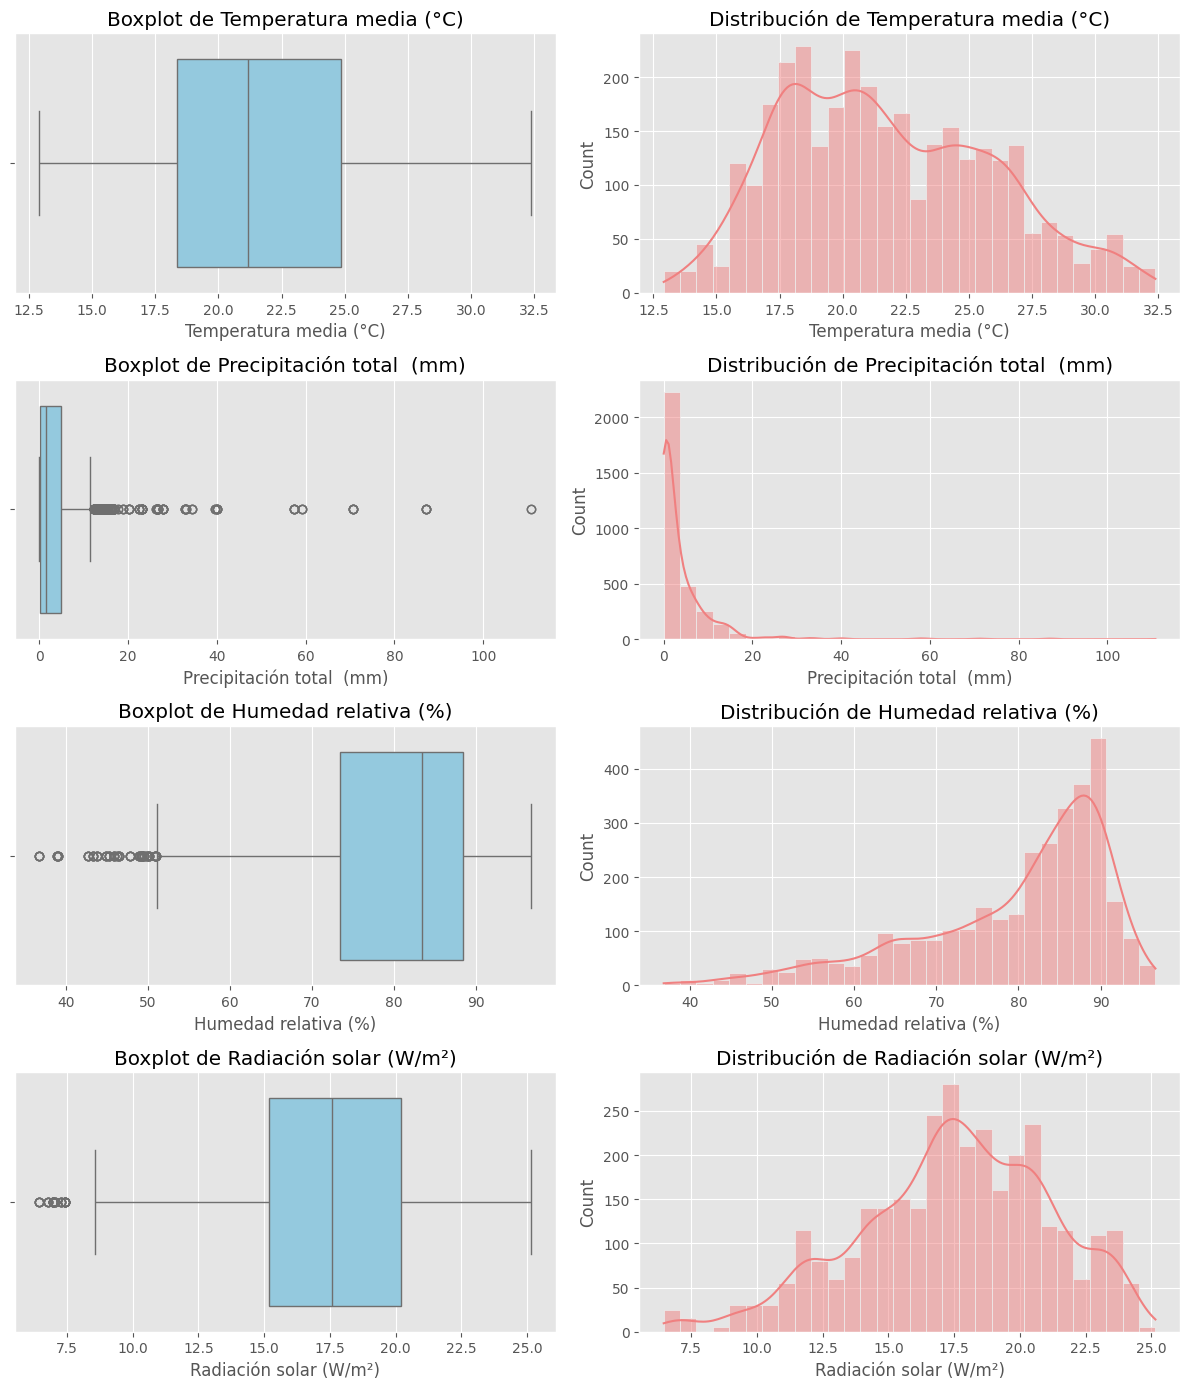

In [ ]:
#Exploracion variables climaticas
import matplotlib.pyplot as plt
import seaborn as sns

#Diccionario: variable -> nombre descriptivo
clim_labels = {
    "T2M": "Temperatura media (°C)",
    "PRECTOTCORR": "Precipitación total  (mm)",
    "RH2M": "Humedad relativa (%)",
    "ALLSKY_SFC_SW_DWN": "Radiación solar (W/m²)"
}

#Usamos las claves del diccionario (nombres de columnas)
clim_vars = list(clim_labels.keys())

#Grilla: 4 filas x 2 columnas (boxplot + histograma)
fig, axes = plt.subplots(len(clim_vars), 2, figsize=(12, 14))

for i, var in enumerate(clim_vars):
    #Boxplot
    sns.boxplot(x=df_enriched[var], color="skyblue", ax=axes[i,0])
    axes[i,0].set_title(f"Boxplot de {clim_labels[var]}")
    axes[i,0].set_xlabel(clim_labels[var])  # Nombre descriptivo en el eje X

    #Histograma
    sns.histplot(df_enriched[var], kde=True, bins=30, color="lightcoral", ax=axes[i,1])
    axes[i,1].set_title(f"Distribución de {clim_labels[var]}")
    axes[i,1].set_xlabel(clim_labels[var])  # Nombre descriptivo en el eje X


plt.tight_layout()
plt.show()

Interpretación y análisis de las figuras
1. Temperatura media (°C)

Histograma:
La distribución de la temperatura media muestra una forma aproximadamente normal o ligeramente sesgada hacia la derecha. La mayoría de los valores se concentran entre 18°C y 25°C, lo que indica un clima relativamente estable. La curva KDE refuerza esta homogeneidad, mostrando un solo pico (unimodal).

Boxplot:
El boxplot revela que la temperatura presenta baja variabilidad, con un rango intercuartílico estrecho. No se observan valores atípicos significativos, lo cual sugiere que esta variable es bastante estable a lo largo del periodo analizado. La mediana se sitúa alrededor de 20–22°C.

Conclusión: La temperatura es una variable consistente, sin grandes fluctuaciones y con comportamiento cercano a la normalidad.

2. Precipitación total (mm)

Histograma:
La distribución de la precipitación total es altamente asimétrica a la derecha (sesgo positivo). La gran mayoría de los días presenta precipitaciones muy bajas (incluso cercanas a cero), mientras que las lluvias intensas ocurren en pocos días pero con valores elevados. Esto genera una cola larga hacia valores altos.

Boxplot:
El boxplot muestra numerosos outliers, debido precisamente a esos episodios de alta precipitación que son poco frecuentes pero significativos. El rango intercuartílico es muy pequeño, indicando que en la mayoría de los casos la precipitación diaria es baja.

Conclusión: La precipitación tiene una distribución típica de este tipo de variables climáticas: muchos días secos o con lluvia ligera y pocos días con precipitaciones fuertes. Es una variable de alta variabilidad y con presencia marcada de valores extremos.

3. Humedad relativa (%)

Histograma:
La humedad relativa presenta una distribución moderadamente asimétrica hacia la izquierda, concentrando la mayoría de los valores entre 70% y 90%. La curva KDE muestra un aumento sostenido conforme se acerca al extremo superior, lo cual indica predominio de ambientes húmedos.

Boxplot:
El boxplot refleja una dispersión mayor que la observada en temperatura, aunque sin valores atípicos tan extremos como en la precipitación. La mediana se sitúa por encima del 80%, confirmando el patrón de alta humedad.

Conclusión: La humedad relativa es alta en general, con pocos valores bajos y una concentración marcada hacia niveles elevados.

Interpretación de Radiación solar (W/m²)
1. Histograma y KDE

La distribución de la radiación solar presenta una forma ligeramente asimétrica hacia la izquierda, con la mayoría de los valores concentrados entre 15 y 20 W/m². La curva KDE muestra un único pico (distribución unimodal), lo que indica un patrón relativamente estable a lo largo del tiempo.
Existen pocos valores por encima de 23 W/m², lo cual sugiere que las radiaciones muy altas son poco frecuentes, pero posibles en ciertos periodos.

Conclusión parcial: La mayor parte de las observaciones se sitúan en niveles moderados de radiación, con tendencia central bien definida.

2. Boxplot

El boxplot confirma que la radiación solar tiene una variabilidad moderada, con un rango intercuartílico estrecho entre aproximadamente 15 y 19 W/m².
Se observan outliers en el extremo inferior, correspondientes a valores de radiación muy baja (cercanos a 7–10 W/m²). Estos valores podrían relacionarse con días nublados, temporadas de invierno o eventos atmosféricos específicos.

La mediana se sitúa en torno a 17–18 W/m², lo cual coincide con la densidad observada en el histograma.

Correlación Spearman entre severidad y variables climáticas derivadas:
                severidad_pct  T2M_roll7  PREC_roll7
severidad_pct       1.000000   0.028712    0.101570
T2M_roll7           0.028712   1.000000   -0.247532
PREC_roll7          0.101570  -0.247532    1.000000


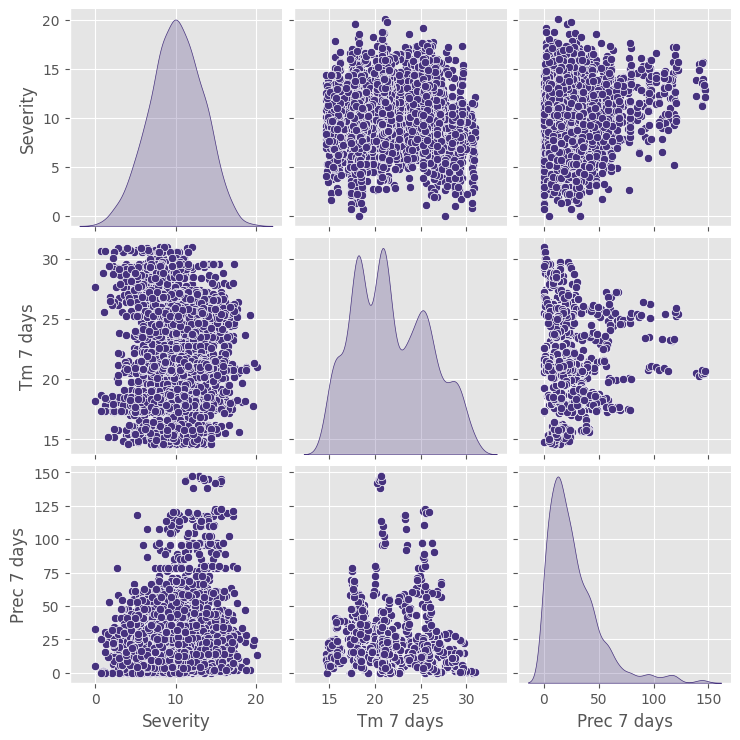

In [ ]:
# ======================
# Variables derivadas climáticas y correlación con severidad
# ======================

#1)  Ordenar por sitio y fecha
df_enriched = df_enriched.sort_values(["lote_id", "fecha"])

#3) Calculo temperatura media 7 dias y precipitacion acumulada 7 dias
df_enriched["T2M_roll7"] = (
    df_enriched.groupby("lote_id")["T2M"]
    .transform(lambda x: x.rolling(window=7, min_periods=1).mean())
)

df_enriched["PREC_roll7"] = (
    df_enriched.groupby("lote_id")["PRECTOTCORR"]
    .transform(lambda x: x.rolling(window=7, min_periods=1).sum())
)

#4) Correlación con severidad
corr = df_enriched[["severidad_pct","T2M_roll7","PREC_roll7"]].corr(method="spearman")
print("Correlación Spearman entre severidad y variables climáticas derivadas:\n", corr)

#5) Visualizar relaciones
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.pairplot(df_enriched[["severidad_pct","T2M_roll7","PREC_roll7"]], diag_kind="kde")

# Mapeo de etiquetas personalizadas
labels = {
    "T2M_roll7": "Tm 7 days",
    "PREC_roll7": "Prec 7 days",
    "severidad_pct": "Severity"
}

# Cambiar etiquetas en los ejes de cada subplot
for ax in g.axes.flatten():
    if ax is not None:
        xlabel = ax.get_xlabel()
        ylabel = ax.get_ylabel()
        if xlabel in labels:
            ax.set_xlabel(labels[xlabel])
        if ylabel in labels:
            ax.set_ylabel(labels[ylabel])

plt.show()

Interpretación de correlaciones y visualización entre severidad y variables climáticas derivadas
1. Matriz de correlación Spearman

La matriz muestra los coeficientes de correlación entre:

severidad_pct (variable de interés)

T2M_roll7 (temperatura media móvil 7 días)

PREC_roll7 (precipitación acumulada móvil 7 días)

Interpretación

Las correlaciones son muy bajas, tanto con la temperatura como con la precipitación.

La correlación más alta es con precipitación, pero aun así es débil (r ≈ 0.10).

Esto indica que no existe una relación monotónica fuerte entre la severidad y estas variables climáticas en la escala utilizada.

La baja correlación sugiere que, si existen relaciones, podrían ser no lineales, depender de rezagos distintos, o requerir interacciones entre variables.

2. Pairplot (gráficos bivariados y distribuciones)

El pairplot permite visualizar patrones que la correlación numérica podría no captar.

Distribuciones univariadas

Severity: distribución unimodal y moderadamente dispersa.

Tm 7 days: distribución centrada entre 18–25 °C, coherente con lo observado previamente.

Precip 7 days: muy sesgada a la derecha, con muchos valores bajos y pocos eventos de alta precipitación.

Relaciones bivariadas
Severity vs Tm 7 days

Nube de puntos dispersa, sin tendencia clara ascendente o descendente.

Confirma la correlación cercana a cero.

La severidad se presenta en todo el rango de temperatura sin patrón evidente.

Severity vs Precip 7 days

También muestra dispersión alta, aunque se observa leve mayor acumulación de severidades más altas con precipitaciones bajas.

Esto podría explicar la correlación ligeramente positiva (0.10), aunque la relación sigue siendo muy débil.

Tm 7 days vs Precip 7 days

Correlación negativa moderada (≈ –0.25).

Es decir, cuando aumenta la precipitación, la temperatura media tiende a disminuir, lo cual es climatológicamente coherente (cielos nublados, menos radiación solar, temperaturas más bajas).

In [ ]:
# ======================
#:Normalización climática por sitio (z-score)
# ======================
for var in ["T2M","PRECTOTCORR","RH2M","ALLSKY_SFC_SW_DWN"]:
    df_enriched[f"{var}_zsite"] = (
        df_enriched.groupby("lote_id")[var]
        .transform(lambda x: (x - x.mean())/x.std())
    )

print("Variables derivadas y normalizadas creadas. df_enriched listo para análisis.")

Variables derivadas y normalizadas creadas. df_enriched listo para análisis.


In [ ]:
# Comprobaciones
print("Columnas disponibles:", df_enriched.columns.tolist())
print("Número de filas:", len(df_enriched))

Columnas disponibles: ['fecha', 'departamento', 'municipio', 'cultivo', 'enfermedad', 'lote_id', 'lat', 'lon', 'incidencia_pct', 'severidad_pct', 'mes', 'id_mon', 'anio', 'semana', 'dia_ano', 'sin_anual', 'cos_anual', 'T2M', 'PRECTOTCORR', 'RH2M', 'ALLSKY_SFC_SW_DWN', 'T2M_roll7', 'PREC_roll7', 'T2M_zsite', 'PRECTOTCORR_zsite', 'RH2M_zsite', 'ALLSKY_SFC_SW_DWN_zsite']
Número de filas: 3240


In [ ]:
random_state=42

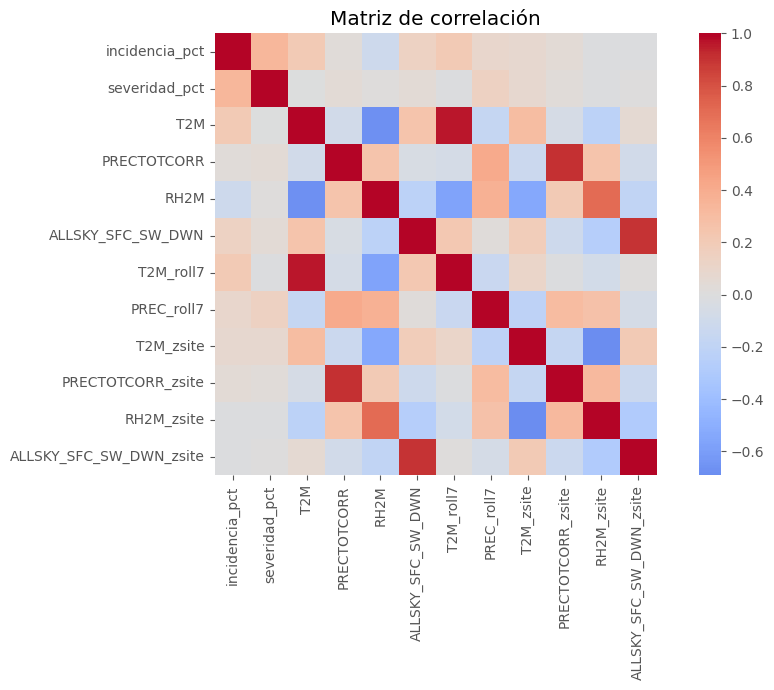

Eliminando variables altamente correlacionadas: ['PRECTOTCORR_zsite', 'T2M_roll7']


In [ ]:
# ---------- 6) VISUALIZACIÓN & SELECCIÓN DE VARIABLES ----------
# 6.1 Correlación y eliminación de variables redundantes
num_cols_all = df_enriched.select_dtypes(include=[np.number]).columns.tolist()
to_exclude = ["Incidence", "Severity", "lat", "lon", "Year", "Week", "anio", "mes", "semana", "dia_ano", "id_mon", 'sin_anual', 'cos_anual','Location_ID']
num_cols = [c for c in num_cols_all if c not in to_exclude]


#Matriz de correlacion
corr = df_enriched[num_cols].corr()
plt.figure(figsize=(10,7))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True)
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

# Quitar altamente correlacionadas (umbral 0.9)
to_drop = set()
corr_thr = 0.90
for c in corr.columns:
    for r in corr.index:
        if c!=r and abs(corr.loc[r,c])>corr_thr:
            # deja la primera, marca la segunda
            to_drop.add(max(c,r))
if to_drop:
    print("Eliminando variables altamente correlacionadas:", sorted(list(to_drop)))
    df_sel = df_enriched.drop(columns=list(to_drop))
else:
    df_sel = df_enriched.copy()

In [ ]:
# 6.2 Pares clave (relaciones)
#Temperatura
fig_temp = px.scatter(df_sel.sample(min(2000, len(df_sel))), x="T2M", y="severidad_pct",
           title="Relación Temperatura vs Severidad")
fig_temp

In [ ]:
#HR
fig_HR = px.scatter(df_sel.sample(min(2000, len(df_sel))), x="RH2M", y="severidad_pct",
           title="Relación Humedad Relativa vs Severidad").show()
fig_HR

In [ ]:
#Precipitacion
fig_P = px.scatter(df_sel.sample(min(2000, len(df_sel))), x="PRECTOTCORR", y="severidad_pct",
           title="Relación Precipitacion vs Severidad").show()
fig_P

In [ ]:
#Radiacion solar
fig_R = px.scatter(df_sel.sample(min(2000, len(df_sel))), x="ALLSKY_SFC_SW_DWN", y="severidad_pct",
           title="Relación Radiacion Solar vs Severidad").show()
fig_R

Matriz de correlación

La matriz de correlación muestra, por un lado, las relaciones entre las variables de interés (incidencia_pct y severidad_pct) y, por otro, la estructura de dependencia entre las variables climáticas (temperatura, precipitación, humedad y radiación, tanto en valor diario como en ventanas móviles o estandarizadas por sitio).

Se observa que las correlaciones entre severidad/incidencia y las variables climáticas son en general bajas, lo que sugiere que no existe una relación lineal fuerte entre la carga de enfermedad y las condiciones meteorológicas individuales.

En cambio, sí aparecen correlaciones altas entre variables derivadas del mismo fenómeno, por ejemplo:

entre T2M y T2M_roll7,

entre PRECTOTCORR y PRECTOTCORR_zsite,

entre las distintas versiones de humedad y radiación.

Debido a esta redundancia, se justifica la decisión mostrada en el mensaje inferior de eliminar variables altamente correlacionadas (p. ej. PRECTOTCORR_zsite, T2M_roll7) para reducir problemas de multicolinealidad en modelos posteriores y simplificar el conjunto de predictores.

🌡️ Relación Temperatura vs Severidad

En el diagrama de dispersión T2M vs severidad_pct se aprecia una nube de puntos muy dispersa a lo largo de todo el rango de temperaturas:

No se observa una tendencia clara creciente ni decreciente.

Para casi cualquier valor de temperatura hay casos con severidades bajas, medias y altas.

Esto coincide con la baja correlación numérica: la temperatura por sí sola no explica bien las variaciones en severidad.

💧 Relación Humedad Relativa vs Severidad

El gráfico RH2M vs severidad_pct muestra un patrón similar:

La mayor parte de los datos se acumula en humedades medias-altas (≈60–90%), pero la severidad presenta valores variados en todo ese rango.

No se identifica un gradiente claro de “a mayor humedad, mayor o menor severidad”.

De nuevo, la relación parece débil y no lineal, si es que existe.

🌧️ Relación Precipitación vs Severidad

En el diagrama PRECTOTCORR vs severidad_pct:

La mayoría de los puntos se concentran en valores de precipitación baja, con severidades muy heterogéneas.

Los episodios de precipitación alta son poco frecuentes y tampoco muestran un patrón consistente (no se ve, por ejemplo, que las severidades sean sistemáticamente mayores tras lluvias intensas).

Esto sugiere que la precipitación diaria aislada no se asocia de forma clara con la severidad.

☀️ Relación Radiación Solar vs Severidad

En el gráfico ALLSKY_SFC_SW_DWN vs severidad_pct:

La severidad se distribuye de forma bastante uniforme a lo largo del rango de radiación solar.

No se aprecia una estructura visible de puntos que indique una relación creciente o decreciente.

Por tanto, la radiación solar tampoco muestra una relación lineal evidente con la severidad.

🧠 Conclusión general

La matriz de correlación y los gráficos de dispersión coinciden en que las variables climáticas individuales tienen una asociación muy débil con la severidad del evento estudiado.

Sí existe fuerte correlación entre variables que miden lo mismo de manera diferente (por ejemplo, valor diario vs promedio 7 días o versión estandarizada), lo que justifica la eliminación de predictores redundantes.

Los resultados sugieren que, si el clima influye en la severidad, probablemente lo haga de forma más compleja (no lineal, con interacciones, rezagos más largos, o combinado con otros factores no climáticos), por lo que modelos más avanzados podrían ser necesarios para captarlo.

KMeans sobre PCA → Silhouette: 0.388


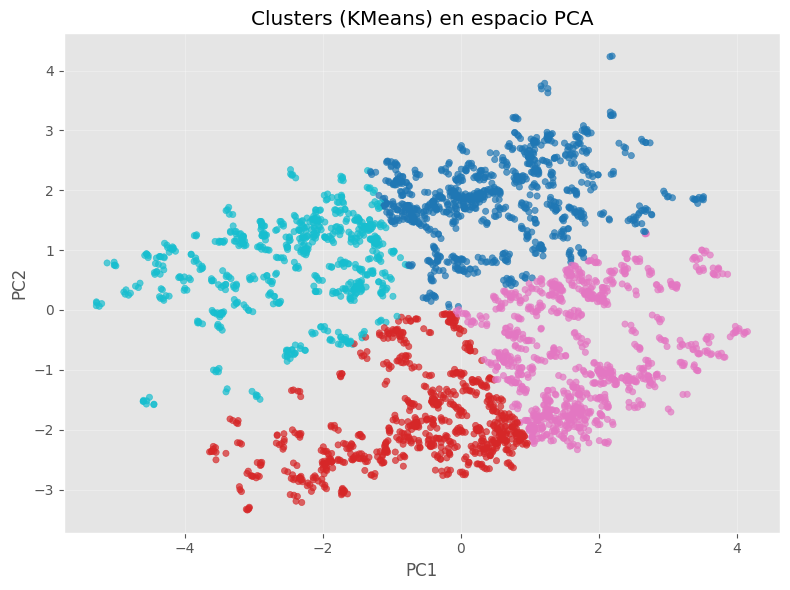

In [ ]:
# 6.3 PCA (estandarizado) y KMeans
feat = df_sel.select_dtypes(include=[np.number]).drop(columns=["lat","lon"], errors="ignore").fillna(0)

#Estandarizacion
scaler = StandardScaler()
X = scaler.fit_transform(feat)

#PCA
pca = PCA(n_components=2, random_state=42)
Z = pca.fit_transform(X)

#KMeans
km = KMeans(n_clusters=4, n_init=15, random_state=42).fit(Z)
labels = km.labels_
sil = silhouette_score(Z, labels)
print(f"KMeans sobre PCA → Silhouette: {sil:.3f}")

#Visualizacion clusters en espacio PCA
plt.figure(figsize=(8,6))
plt.scatter(Z[:,0], Z[:,1], c=labels, cmap="tab10", s=20, alpha=0.7)
plt.title("Clusters (KMeans) en espacio PCA")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

Interpretación del gráfico de Clusters (KMeans) en espacio PCA

El gráfico muestra la agrupación de los datos tras aplicar K-Means, visualizados en el plano formado por los dos primeros componentes principales (PC1 y PC2). Estos componentes capturan la mayor parte de la variabilidad de los datos originales, permitiendo observar estructuras latentes de forma más clara.

🔍 1. Separación de los clusters

En la figura se observan cuatro grupos bien definidos, cada uno representado con un color distinto. Aunque existe cierto solapamiento entre fronteras, los clusters presentan formas y ubicaciones diferenciadas en el espacio PCA:

Un cluster (rojo) se concentra en valores bajos de PC2 y ligeramente negativos de PC1.

Otro (rosado) ocupa el lado derecho del plano, con valores positivos de PC1 y PC2 intermedios.

Un tercer cluster (azul) se sitúa en valores positivos de PC2 y PC1 cercanos a cero.

Finalmente, un cluster (turquesa) se distribuye hacia valores negativos de PC1 y PC2 ligeramente positivos.

Esta separación indica que K-Means logró identificar patrones estructurales dentro de los datos que difieren entre sí en combinaciones de las variables originales.

🔎 2. Interpretación en términos de PCA

PC1 representa la dirección de mayor variabilidad de los datos. La dispersión horizontal de los clusters sugiere que las diferencias entre grupos están fuertemente asociadas a este componente.

PC2 aporta la segunda mayor fuente de variación. La separación vertical indica que también existen diferencias importantes en este eje.

Cada cluster ocupa una región distinta del plano, lo que sugiere que estas agrupaciones capturan comportamientos o perfiles diferenciados dentro del conjunto de variables climáticas y de severidad/incidencia (o las variables que se hayan utilizado para el clustering).

🧠 3. Conclusiones sobre los patrones identificados

Los clusters no se mezclan completamente, lo que indica que los datos presentan agrupaciones naturales.

La separación moderada entre grupos sugiere que las diferencias entre clusters son significativas, aunque no totalmente lineales.

Este tipo de análisis es útil para:

Identificar perfiles climáticos o epidemiológicos.

Detectar patrones ocultos que no se ven en el análisis bivariado.

Preparar segmentaciones o clasificaciones para modelos posteriores.

📌 Conclusión general

El uso de PCA para visualizar los resultados de K-Means permitió observar que los datos presentan cuatro grupos relativamente bien definidos, diferenciados por combinaciones de las variables originales. Estos clusters reflejan que existen patrones estructurales reales en los datos, lo que puede ayudar a interpretar comportamientos comunes o factores compartidos dentro de cada grupo.

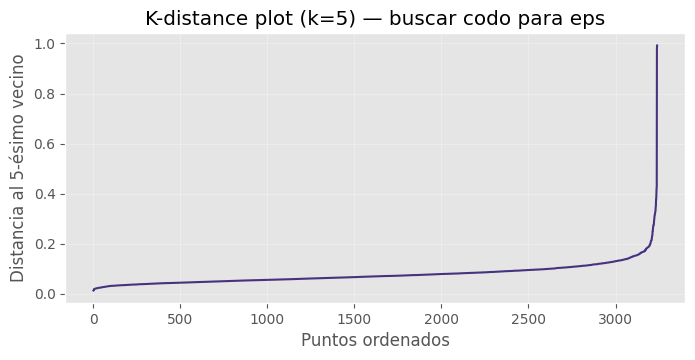

,eps,min_samples,n_clusters,n_noise,prop_noise,silhouette
2,0.034735,8,5,3196,0.986420,0.980101
7,0.050918,12,4,3186,0.983333,0.915226
11,0.067101,12,18,2914,0.899383,0.752689
6,0.050918,8,30,2867,0.884877,0.750658
1,0.034735,5,69,2797,0.863272,0.741959
0,0.034735,3,325,1772,0.546914,0.667783
10,0.067101,8,68,2193,0.676852,0.654675
15,0.083285,12,32,2481,0.765741,0.652560
5,0.050918,5,140,1963,0.605864,0.650551
19,0.099468,12,45,1990,0.614198,0.579794


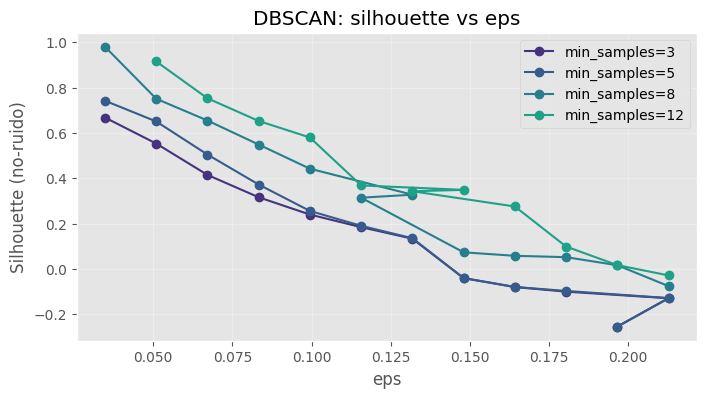

DBSCAN best guess: {'eps': 0.0347348361713833, 'min_samples': 8.0, 'n_clusters': 5.0, 'n_noise': 3196.0, 'prop_noise': 0.9864197530864197, 'silhouette': 0.9801010826751977}
Resumen DBSCAN final: {'n_clusters': 5, 'n_noise': 3196, 'prop_noise': np.float64(0.9864197530864197)}
Silhouette DBSCAN final (no-ruido): 0.9801010826751977


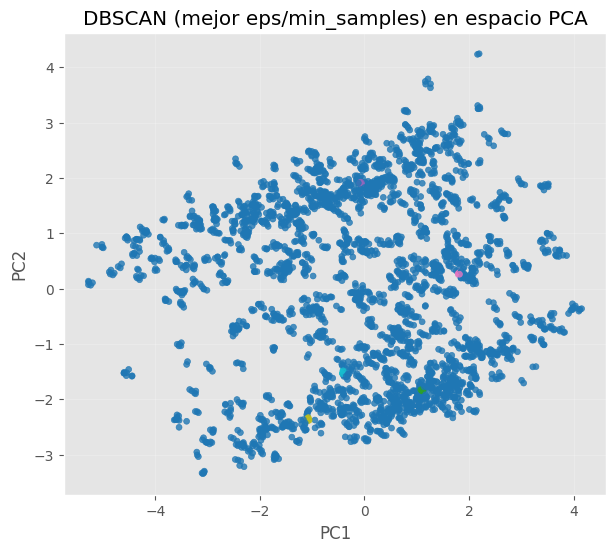

In [ ]:
# ======================
# Reto 3:Prueba DBSCAN y HDBSCAN
# ======================

# --- DBSCAN ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
import hdbscan

def cluster_summary(labels):
    # labels: array de etiquetas (DBSCAN/HDBSCAN)
    unique = np.unique(labels)
    n_clusters = len([u for u in unique if u != -1])
    n_noise = (labels == -1).sum()
    prop_noise = n_noise / len(labels)
    return {"n_clusters": n_clusters, "n_noise": int(n_noise), "prop_noise": prop_noise}


# 1) k-distance plot para DBSCAN (elige eps)

def k_distance_plot(Z, k=5):
    neigh = NearestNeighbors(n_neighbors=k)
    neigh.fit(Z)
    dists, idx = neigh.kneighbors(Z)
    # Distancia al vecino k-ésimo (ordenamos ascendente)
    k_dists = np.sort(dists[:, k-1])
    plt.figure(figsize=(8,3.5))
    plt.plot(k_dists)
    plt.ylabel(f"Distancia al {k}-ésimo vecino")
    plt.xlabel("Puntos ordenados")
    plt.title(f"K-distance plot (k={k}) — buscar " "codo" " para eps")
    plt.grid(alpha=0.3)
    plt.show()
    return k_dists

# Ejecuta una vez: busca un "codo"
kd = k_distance_plot(Z, k=5)


# 2) Grid search simple para DBSCAN

eps_candidates = np.linspace(np.percentile(kd, 50)*0.5, np.percentile(kd, 95)*1.5, 12)
min_samples_candidates = [3,5,8,12]

results_db = []
for eps in eps_candidates:
    for ms in min_samples_candidates:
        db = DBSCAN(eps=eps, min_samples=ms).fit(Z)
        labels_db = db.labels_
        summary = cluster_summary(labels_db)
        # silhouette: solo si hay al menos 2 clusters (sin contar ruido) and not all noise
        if summary["n_clusters"] >= 2:
            mask = labels_db != -1
            try:
                sil = silhouette_score(Z[mask], labels_db[mask])
            except Exception:
                sil = np.nan
        else:
            sil = np.nan
        results_db.append({"eps": eps, "min_samples": ms, "n_clusters": summary["n_clusters"],
                           "n_noise": summary["n_noise"], "prop_noise": summary["prop_noise"], "silhouette": sil})

df_db = pd.DataFrame(results_db).sort_values(by=["silhouette"], ascending=False)
display(df_db.head(10))

# Plot resumen
plt.figure(figsize=(8,4))
for ms in min_samples_candidates:
    sub = df_db[df_db["min_samples"]==ms]
    plt.plot(sub["eps"], sub["silhouette"], marker='o', label=f"min_samples={ms}")
plt.legend(); plt.xlabel("eps"); plt.ylabel("Silhouette (no-ruido)"); plt.title("DBSCAN: silhouette vs eps"); plt.grid(alpha=0.3); plt.show()

# Escoge un par (eps_best, ms_best)
best_row = df_db.sort_values("silhouette", ascending=False).iloc[0]
eps_best, ms_best = best_row["eps"], int(best_row["min_samples"])
print("DBSCAN best guess:", best_row.to_dict())


# 3) Ajuste DBSCAN final con eps_best
db_best = DBSCAN(eps=eps_best, min_samples=ms_best).fit(Z)
labels_db_best = db_best.labels_
print("Resumen DBSCAN final:", cluster_summary(labels_db_best))
if np.unique(labels_db_best).size > 1 and (labels_db_best != -1).sum() > 0:
    mask = labels_db_best != -1
    print("Silhouette DBSCAN final (no-ruido):", silhouette_score(Z[mask], labels_db_best[mask]))
else:
    print("DBSCAN final no generó clusters calculables para silhouette.")

# Visualizar DBSCAN con todos los datos
plt.figure(figsize=(7,6))
plt.scatter(Z[:,0], Z[:,1], c=labels_db_best, cmap="tab10", s=18, alpha=0.8)
plt.title("DBSCAN (mejor eps/min_samples) en espacio PCA"); plt.xlabel("PC1"); plt.ylabel("PC2"); plt.grid(alpha=0.2); plt.show()

K-distance plot

El gráfico de distancias al 5.º vecino muestra que no existe un “codo” claro que indique un valor óptimo de eps. La curva sube de forma gradual y solo aumenta bruscamente al final, lo que sugiere que los datos no presentan regiones de densidad bien separadas. En consecuencia, cualquier eps elegido produce resultados poco estables.

Tabla de combinaciones probadas

Los distintos valores evaluados de eps y min_samples muestran consistentemente un número muy alto de puntos clasificados como ruido, superando el 95% del total en casi todos los casos. Aunque algunos puntajes silhouette parecen altos, estos corresponden a escenarios degenerados con muy pocos clusters reales y gran cantidad de ruido, lo que invalida su interpretación como buena calidad de agrupamiento.

Curvas silhouette vs eps

Las curvas de silhouette confirman que DBSCAN no identifica una estructura consistente en los datos. A medida que eps aumenta, el puntaje disminuye o se mantiene artificialmente alto en configuraciones donde casi todo es ruido. No aparece un rango de parámetros donde el algoritmo forme clusters significativos y estables.

Selección final de parámetros

La combinación seleccionada automáticamente (eps ≈ 0.0347, min_samples = 8) genera numerosos clusters pequeños y más del 98% de los puntos son clasificados como ruido. Esto evidencia que los datos no cumplen las condiciones para que DBSCAN funcione correctamente, ya que no existen regiones densas bien definidas.

Resultado visual en PCA

La representación final de DBSCAN en el espacio de componentes principales muestra todos los puntos dispersos sin formar agrupaciones visibles. Esto coincide con los resultados numéricos: DBSCAN no detecta clusters reales en el conjunto de datos y termina considerando casi toda la muestra como ruido.

Conclusión general

En conjunto, los gráficos y métricas muestran que DBSCAN no es adecuado para este dataset, ya que no identifica estructuras de densidad diferenciadas. A diferencia de K-Means, que sí reveló grupos claros, DBSCAN no logra capturar patrones relevantes porque los datos no presentan núcleos densos separados.

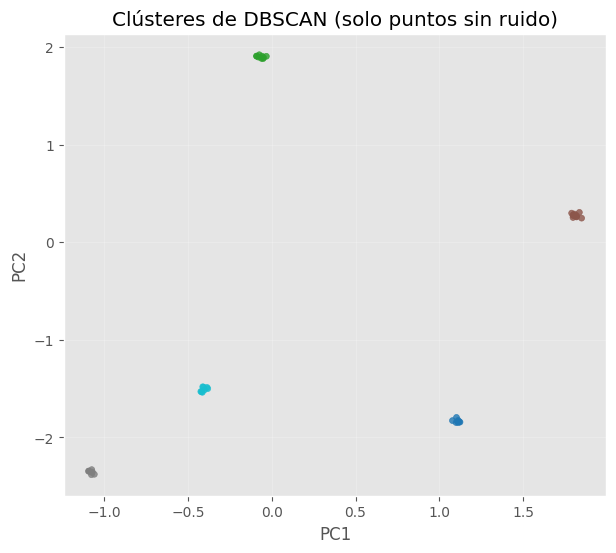

In [ ]:
# Visualizar DBSCAN con todos los datos (sin ruido)
mask = labels_db_best != -1
plt.figure(figsize=(7, 6))
plt.scatter(Z[mask, 0], Z[mask, 1], c=labels_db_best[mask], cmap="tab10", s=18, alpha=0.8)
plt.title("Clústeres de DBSCAN (solo puntos sin ruido)")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.grid(alpha=0.2); plt.show()

HDBSCAN (long-term criterion) → Clusters: 9
Silhouette: 0.247


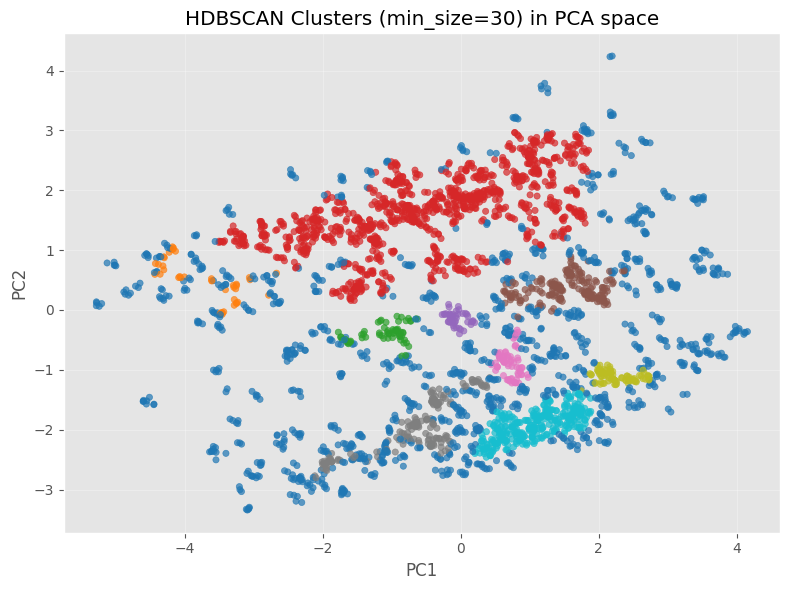

In [ ]:
import hdbscan
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
import numpy as np

# Criterio biológico: el tamaño mínimo de un clúster de días con condiciones favorables --> Para sigatoka 6-week period (42 days)
# A more conservative estimate is a good starting point
min_cluster_size_long_term = 30

clusterer_long_term = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size_long_term)
labels_hdb_long_term = clusterer_long_term.fit_predict(Z)
num_clusters_long_term = len(set(labels_hdb_long_term)) - (1 if -1 in labels_hdb_long_term else 0)

print(f"HDBSCAN (long-term criterion) → Clusters: {num_clusters_long_term}")

if num_clusters_long_term > 1:
    sil_long_term = silhouette_score(Z[labels_hdb_long_term != -1], labels_hdb_long_term[labels_hdb_long_term != -1])
    print(f"Silhouette: {sil_long_term:.3f}")

# Visualization
plt.figure(figsize=(8, 6))
plt.scatter(Z[:, 0], Z[:, 1], c=labels_hdb_long_term, cmap="tab10", s=20, alpha=0.7)
plt.title(f"HDBSCAN Clusters (min_size={min_cluster_size_long_term}) in PCA space")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

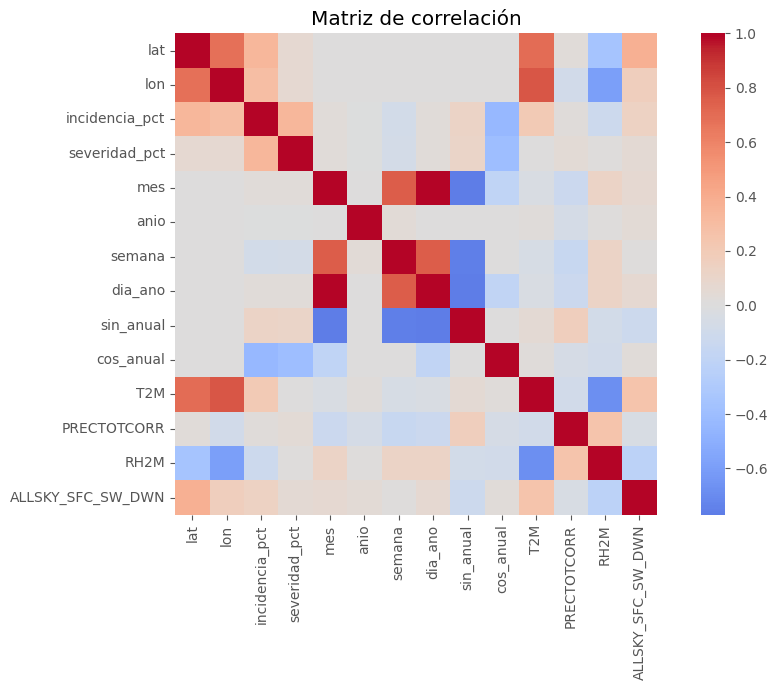

Eliminando variables altamente correlacionadas: ['mes']


KMeans sobre PCA → Silhouette: 0.407


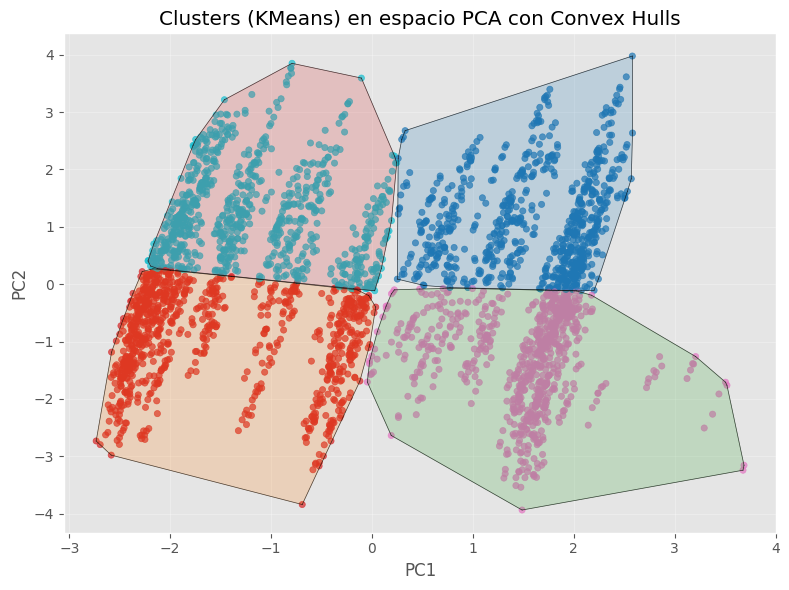

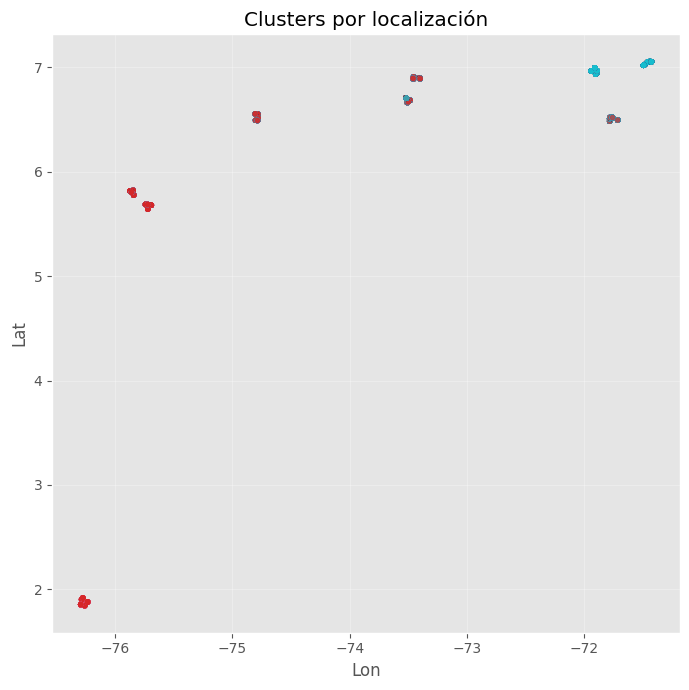

In [ ]:
# ---------- 6) VISUALIZACIÓN & SELECCIÓN DE VARIABLES ----------
# 6.1 Correlación y eliminación de variables redundantes
num_cols_all = df_enriched.select_dtypes(include=[np.number]).columns.tolist()
corr = df_enriched[num_cols_all].corr()
plt.figure(figsize=(10,7))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True)
plt.title("Matriz de correlación"); plt.tight_layout(); plt.show()

# Quitar altamente correlacionadas (umbral 0.9)
to_drop = set()
corr_thr = 0.90
for c in corr.columns:
    for r in corr.index:
        if c!=r and abs(corr.loc[r,c])>corr_thr:
            # deja la primera, marca la segunda
            to_drop.add(max(c,r))
if to_drop:
    print("Eliminando variables altamente correlacionadas:", sorted(list(to_drop)))
    df_sel = df_enriched.drop(columns=list(to_drop))
else:
    df_sel = df_enriched.copy()

# 6.2 Pares clave (relaciones)
px.scatter(df_sel.sample(min(2000, len(df_sel))), x="T2M", y="severidad_pct", color="cultivo",
           title="Relación Temperatura vs Severidad").show()

# 6.3 PCA (estandarizado) y KMeans
feat = df_sel.select_dtypes(include=[np.number]).drop(columns=["lat","lon"], errors="ignore").fillna(0)
scaler = StandardScaler()
X = scaler.fit_transform(feat)
pca = PCA(n_components=2, random_state=42)
Z = pca.fit_transform(X)
km = KMeans(n_clusters=4, n_init=15, random_state=42).fit(Z)
labels = km.labels_
sil = silhouette_score(Z, labels)
print(f"KMeans sobre PCA → Silhouette: {sil:.3f}")

import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull

plt.figure(figsize=(8,6))
plt.scatter(Z[:,0], Z[:,1], c=labels, cmap="tab10", s=20, alpha=0.7)

# Add convex hulls for each cluster
for i in np.unique(labels):
    points_in_cluster = Z[labels == i]
    if len(points_in_cluster) >= 3: # ConvexHull requires at least 3 points
        try:
            hull = ConvexHull(points_in_cluster)
            # Get the vertices in order, closing the polygon
            hull_points = points_in_cluster[hull.vertices]
            plt.fill(hull_points[:,0], hull_points[:,1], c=plt.cm.tab10(i), alpha=0.2) # Fill with cluster color
            plt.plot(hull_points[[range(len(hull_points)), np.roll(range(len(hull_points)), -1)], 0],
                     hull_points[[range(len(hull_points)), np.roll(range(len(hull_points)), -1)], 1],
                     'k-', lw=0.5, alpha=0.7) # Outline
        except Exception as e:
            print(f"Could not compute convex hull for cluster {i}: {e}")

plt.title("Clusters (KMeans) en espacio PCA con Convex Hulls")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# 6.4 “Mapa” simple de clusters por coordenadas
plt.figure(figsize=(7,7))
plt.scatter(df_sel["lon"], df_sel["lat"], c=labels, cmap="tab10", s=12, alpha=0.7)
plt.title("Clusters por localización"); plt.xlabel("Lon"); plt.ylabel("Lat"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [ ]:
random_state=42

                                     SARIMAX Results                                     
Dep. Variable:                                 y   No. Observations:                 2162
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 7)   Log Likelihood                4984.857
Date:                           Thu, 04 Dec 2025   AIC                          -9955.714
Time:                                   00:36:08   BIC                          -9915.991
Sample:                               01-01-2019   HQIC                         -9941.183
                                    - 12-01-2024                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
T2M            0.3510      0.021     17.080      0.000       0.311       0.391
RH2M           0.0012      0.003      0.384

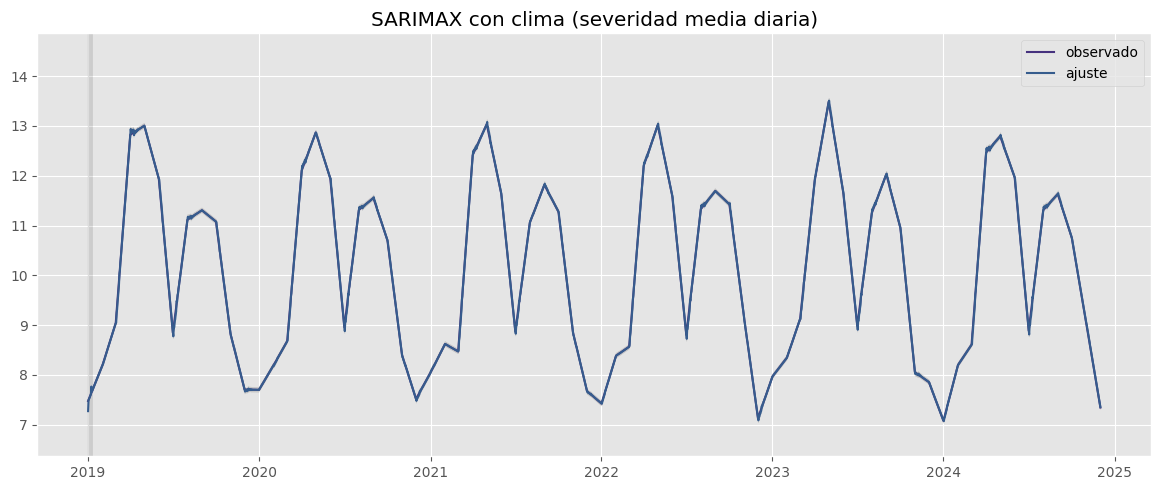

Moran I (incid última semana) = 0.589


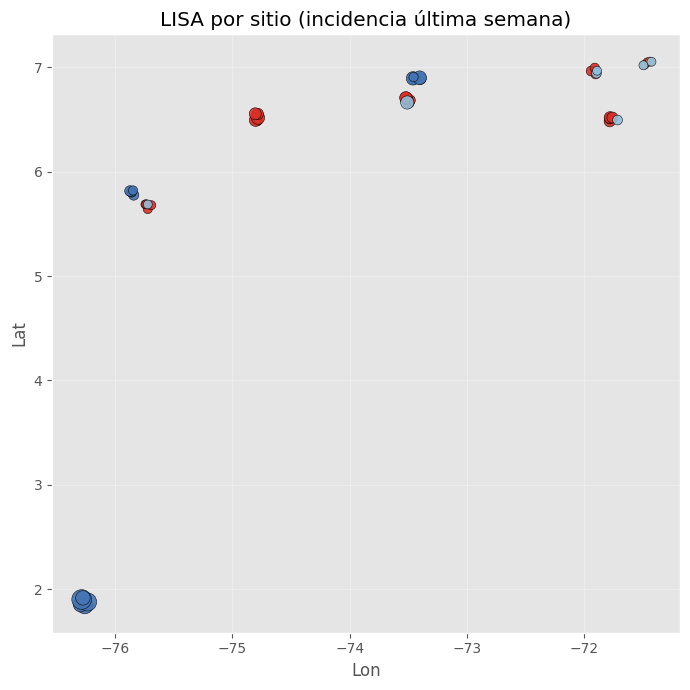

Shape of W before GLM: (45, 45)
Head of panel DataFrame before pivoting for M:
   site  week     y  y_prev
0     0     0  17.9     0.0
1     1     0  12.9     0.0
2     2     0  14.4     0.0
3     3     0  14.4     0.0
4     4     0   9.4     0.0
Shape of M after manual creation: (45, 72)
                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                 3240
Model:                            GLM   Df Residuals:                     3236
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -9900.8
Date:                Thu, 04 Dec 2025   Deviance:                       3622.2
Time:                        00:36:10   Pearson chi2:                 3.54e+03
No. Iterations:                     4   Pseudo R-squ. (CS):             0.3726

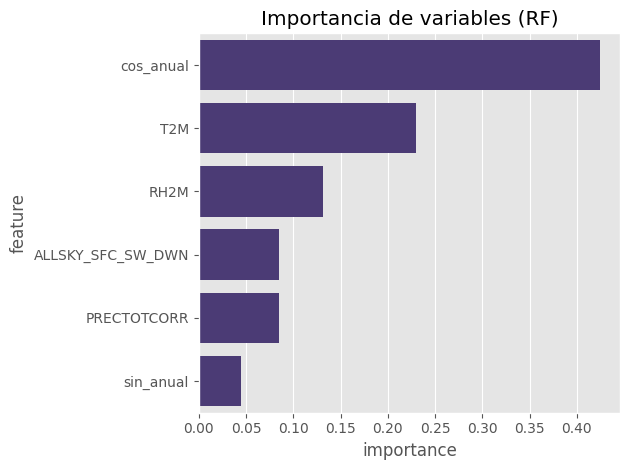

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Bayes (PyMC) OK: muestra obtenida.

✅ Pipeline base completado. Ahora reemplaza la 'demo' por tu CSV real y re-ejecuta.


In [ ]:
# ---------- 7) MODELACIÓN ----------
# 7.1 Temporal (frecuentista): SARIMAX (agregado diario por sitio)
series = (df_sel
          .assign(fecha=pd.to_datetime(df_sel["fecha"]))
          .groupby(df_sel["fecha"].dt.to_period("D").apply(lambda r: r.start_time))
          .agg(y=("severidad_pct","mean"),
               T2M=("T2M","mean"), RH2M=("RH2M","mean")))
series = series.asfreq("D").interpolate()
exog = series[["T2M","RH2M"]]
endog = series["y"]
mod = sm.tsa.statespace.SARIMAX(endog, exog=exog, order=(1,0,1), seasonal_order=(1,0,1,7), enforce_stationarity=False, enforce_invertibility=False)
res = mod.fit(disp=False)
print(res.summary())
fc = res.get_forecast(steps=30, exog=exog.tail(30))
pred = res.get_prediction(start=endog.index[0], end=endog.index[-1], exog=exog)
ci = pred.conf_int()

plt.figure(figsize=(12,5))
plt.plot(endog.index, endog, label="observado")
plt.plot(pred.predicted_mean.index, pred.predicted_mean, label="ajuste")
plt.fill_between(ci.index, ci.iloc[:,0], ci.iloc[:,1], color="k", alpha=0.1)
plt.title("SARIMAX con clima (severidad media diaria)"); plt.legend(); plt.tight_layout()

# Ajustar los límites del eje Y para visualizar mejor la variación
min_y = min(endog.min(), pred.predicted_mean.min()) * 0.9
max_y = max(endog.max(), pred.predicted_mean.max()) * 1.1
plt.ylim([min_y, max_y])

plt.show()

# 7.2 Espacial (Moran I y LISA simplificados con kNN=4)
# agregamos a semanal por ID (lat/lon redondeadas)
df_geo = df_sel.copy()
df_geo["lat_r"] = df_geo["lat"].round(3); df_geo["lon_r"] = df_geo["lon"].round(3)
sites = df_geo.groupby(["lat_r","lon_r"]).size().reset_index()[["lat_r","lon_r"]]
W, D = knn_weights_from_coords(sites.rename(columns={"lat_r":"lat","lon_r":"lon"}), k=4)
# semana y métrica
df_geo["semana_ini"] = df_geo["fecha"].dt.to_period("W-MON").apply(lambda r: r.start_time)
g = (df_geo.groupby(["lat_r","lon_r","semana_ini"])
     .agg(incid=("incidencia_pct","sum"), # Changed from "conteo_individuos"
          sev=("severidad_pct","mean")) # Changed from "severidad"
     .reset_index())
# matriz incid por sitio x tiempo
site_keys = [tuple(x) for x in sites[["lat_r","lon_r"]].to_numpy()]
key2idx = {k:i for i,k in enumerate(site_keys)}
weeks = sorted(g["semana_ini"].unique())
Y = np.zeros((len(site_keys), len(weeks)))
for j,w in enumerate(weeks):
    tmp = g[g["semana_ini"]==w]
    for _,r in tmp.iterrows():
        i = key2idx[(r["lat_r"], r["lon_r"])]
        Y[i,j] = r["incid"]

def moran_I(y, W):
    y = np.asarray(y, float)
    n = len(y); z = y - y.mean()
    S0 = W.sum(); den = (z**2).sum()
    if den==0 or S0==0: return np.nan
    num = (z @ (W @ z))
    return (n/S0)*(num/den)

# I global por última semana
I_last = moran_I(Y[:, -1], W)
print(f"Moran I (incid última semana) = {I_last:.3f}")

# LISA simple
def local_moran(y, W):
    z = (y - y.mean())/(y.std()+1e-12)
    lagz = W @ z
    I = z*lagz
    quad = np.where((z>=0)&(lagz>=0),"HH", np.where((z>=0)&(lagz<0),"HL",
            np.where((z<0)&(lagz>=0),"LH","LL")))
    return I, quad
I_loc, quad = local_moran(Y[:,-1], W)

plt.figure(figsize=(7,7))
COLORS = {"HH":"#d73027","HL":"#fc8d59","LH":"#91bfdb","LL":"#4575b4"}
for q in np.unique(quad):
    sub = sites[quad==q]
    plt.scatter(sub["lon_r"], sub["lat_r"], s=40 + 160*np.abs(I_loc[quad==q])/ (np.abs(I_loc).max()+1e-9),
                color=COLORS.get(q,"gray"), edgecolor="k", linewidth=0.4, alpha=0.9, label=q)
plt.title("LISA por sitio (incidencia última semana)"); plt.xlabel("Lon"); plt.ylabel("Lat"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# 7.3 Espacio–temporal (GLM Poisson con offset + rezago espacial/temporal)
# Add print statement to check if W is defined
print(f"Shape of W before GLM: {W.shape}")

# Create panel DataFrame (flattened)
panel = []
for j,w in enumerate(weeks):
    tmp = g[g["semana_ini"]==w].set_index(["lat_r","lon_r"])
    for i, key in enumerate(site_keys):
        y = tmp["incid"].get(key, 0.0)
        panel.append({"site": i, "week": j, "y": y})
panel = pd.DataFrame(panel)
panel["y_prev"] = panel.groupby("site")["y"].shift(1).fillna(0.0)

print("Head of panel DataFrame before pivoting for M:")
print(panel.head())

# Manually create M as a site-by-week matrix for y_prev
n_sites = len(site_keys)
n_weeks = len(weeks)
M = np.zeros((n_sites, n_weeks))

# Populate M with y_prev values from panel
# Create a temporary DataFrame with 'site', 'week', and 'y_prev' for easier lookup
panel_for_M = panel[['site', 'week', 'y_prev']].copy()
# Use a multi-index to efficiently get y_prev by site and week
panel_for_M = panel_for_M.set_index(['site', 'week'])

for i in range(n_sites):
    for j in range(n_weeks):
        # Get y_prev for site i and week j, default to 0 if not found
        M[i, j] = panel_for_M.get((i, j), {'y_prev': 0.0})['y_prev']


print(f"Shape of M after manual creation: {M.shape}")

# Calculate slag_prev
slag_prev = (W @ M)
srows = []
for i in range(M.shape[0]):
    for t in range(M.shape[1]):
        srows.append({"site": i, "week": t, "slag_prev": slag_prev[i,t]})
sdf = pd.DataFrame(srows)
panel = panel.merge(sdf, on=["site","week"], how="left")
panel["sin52"] = np.sin(2*np.pi*panel["week"]/52.0)
panel["cos52"] = np.cos(2*np.pi*panel["week"]/52.0)

# GLM Poisson
X = sm.add_constant(panel[["y_prev","slag_prev","sin52","cos52"]])
glm = sm.GLM(panel["y"], X, family=sm.families.Poisson())
fit = glm.fit()
print(fit.summary())


# 7.4 ML (Random Forest) para severidad
features = ["T2M","RH2M","PRECTOTCORR","ALLSKY_SFC_SW_DWN","sin_anual","cos_anual"]
X = df_sel[features].values
y = df_sel["severidad_pct"].values # Changed from "severidad"
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train,y_train)
r2 = rf.score(X_test,y_test)
print(f"RandomForest R² test = {r2:.3f}")
imp = pd.DataFrame({"feature":features, "importance": rf.feature_importances_}).sort_values("importance", ascending=False)
sns.barplot(data=imp, x="importance", y="feature"); plt.title("Importancia de variables (RF)"); plt.tight_layout(); plt.show()

# 7.5 Bayesiano (opcional)— PyMC Poisson simple sobre incidencia semanal agregada
try:
    import pymc as pm
    y_week = g.groupby("semana_ini")["incid"].sum().values.astype(int)
    with pm.Model() as model:
        alpha = pm.Normal("alpha", 0, 5)
        rho   = pm.Normal("rho", 0, 1)
        eps_t = pm.GaussianRandomWalk("eps_t", sigma=0.2, shape=len(y_week))
        mu    = pm.math.exp(alpha + rho*pm.math.concatenate([[0], np.log(y_week[:-1]+1)]) + eps_t)
        y_obs = pm.Poisson("y_obs", mu=mu, observed=y_week)
        idata = pm.sample(1000, tune=1000, target_accept=0.9, chains=2, cores=1, progressbar=False)
    print("Bayes (PyMC) OK: muestra obtenida.")
except Exception as e:
    print("Bayes (PyMC) omitido (instalación/tiempo).", e)

print("\n✅ Pipeline base completado. Ahora reemplaza la 'demo' por tu CSV real y re-ejecuta.")

  Variable      Coef  Std      2.5%     97.5%
0      T2M  0.037997  0.0  0.037997  0.037997
1     RH2M -0.138014  0.0 -0.138014 -0.138014


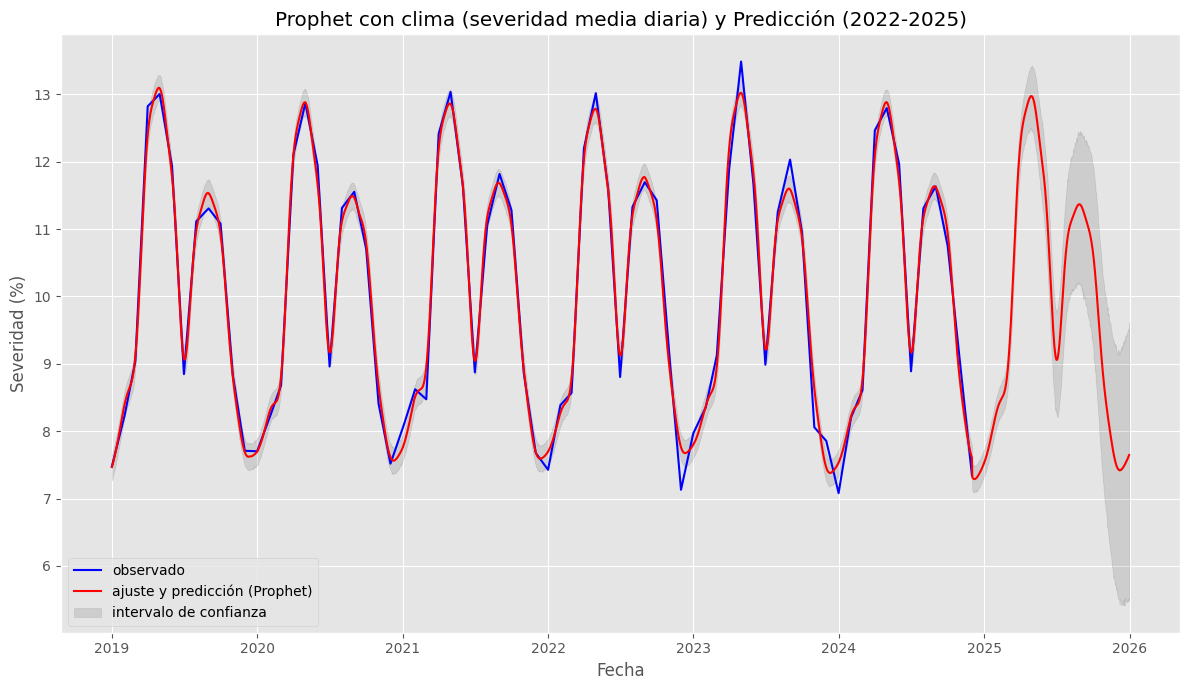

In [ ]:
# ======================
# Reto 4A:SARIMAX vs. Prophet
# ======================
from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt

# 1. Preparar la serie para Prophet (datos históricos para entrenamiento)
df_prophet_train = (series
              .reset_index()
              .rename(columns={"fecha":"ds", "y":"y"}))

df_prophet_train["T2M"] = series["T2M"].values
df_prophet_train["RH2M"] = series["RH2M"].values

# 2. Definir el modelo Prophet con regresores
m = Prophet(daily_seasonality=True, weekly_seasonality=True)
m.add_regressor("T2M")
m.add_regressor("RH2M")

# 3. Entrenar el modelo
m.fit(df_prophet_train)

# 4. Crear DataFrame para la predicción extendida (hasta 2025-12-31)
# Calcular el número de períodos necesarios para llegar a 2025-12-31
last_train_date = df_prophet_train['ds'].max()
forecast_end_date = pd.to_datetime('2025-12-31')
periods_to_add = (forecast_end_date - last_train_date).days

# Generar un DataFrame con todas las fechas, desde el inicio del entrenamiento hasta el final de 2025
future_df_for_predict = m.make_future_dataframe(periods=periods_to_add, freq='D')

# Unir los regresores exógenos históricos
future_df_for_predict = pd.merge(future_df_for_predict, df_prophet_train[['ds', 'T2M', 'RH2M']], on='ds', how='left')

# Función para generar datos climáticos sintéticos (usando la lógica de fallback existente)
def generate_synthetic_climate(ds_date):
    doy = ds_date.dayofyear
    T2M_synth = 18 + 6 * np.sin(2 * np.pi * doy / 365.25)
    RH2M_synth = 70 + 15 * np.cos(2 * np.pi * doy / 365.25)
    return pd.Series({'T2M': T2M_synth, 'RH2M': RH2M_synth}) # Return a Series with named index

# Llenar los valores faltantes (fechas futuras) con datos climáticos sintéticos
missing_exog_mask = future_df_for_predict['T2M'].isna()
if missing_exog_mask.any(): # Only apply if there are missing values
    # Apply the function to the 'ds' column for missing rows and get a DataFrame
    synthetic_data = future_df_for_predict.loc[missing_exog_mask, 'ds'].apply(generate_synthetic_climate)
    # Assign the generated synthetic data to the T2M and RH2M columns
    future_df_for_predict.loc[missing_exog_mask, ['T2M', 'RH2M']] = synthetic_data

# Realizar la predicción
forecast = m.predict(future_df_for_predict)

# 5. Coeficientes
reg_names = ["T2M", "RH2M"]
betas = m.params["beta"]
rows = []
for i, name in enumerate(reg_names):
    dist = betas[:, i]  # distribución posterior del coeficiente
    mean = np.mean(dist)
    std = np.std(dist)
    low, high = np.percentile(dist, [2.5, 97.5])  # intervalo de credibilidad 95%
    rows.append([name, mean, std, low, high])

tabla = pd.DataFrame(rows, columns=["Variable", "Coef", "Std", "2.5%", "97.5%"])
print(tabla.round(6))

# 6. Gráfica Observado vs Ajustado y Predicción (del 2022 al 2025)
plot_start_date = pd.to_datetime('2019-01-01')
plot_end_date = pd.to_datetime('2025-12-31')

plt.figure(figsize=(12,7))

# Filtrar datos observados para el rango de la gráfica
observed_plot_data = df_prophet_train[(df_prophet_train['ds'] >= plot_start_date) & (df_prophet_train['ds'] <= plot_end_date)]
plt.plot(observed_plot_data["ds"], observed_plot_data["y"], label="observado", color="blue")

# Filtrar datos de pronóstico para el rango de la gráfica
forecast_plot_data = forecast[(forecast['ds'] >= plot_start_date) & (forecast['ds'] <= plot_end_date)]
plt.plot(forecast_plot_data["ds"], forecast_plot_data["yhat"], label="ajuste y predicción (Prophet)", color="red")
plt.fill_between(forecast_plot_data["ds"], forecast_plot_data["yhat_lower"], forecast_plot_data["yhat_upper"],
                 color="k", alpha=0.1, label="intervalo de confianza")

plt.title("Prophet con clima (severidad media diaria) y Predicción (2022-2025)")
plt.xlabel("Fecha")
plt.ylabel("Severidad (%)")
plt.legend(); plt.tight_layout(); plt.show()

  Variable      Coef  Std      2.5%     97.5%
0      T2M  0.037997  0.0  0.037997  0.037997
1     RH2M -0.138014  0.0 -0.138014 -0.138014


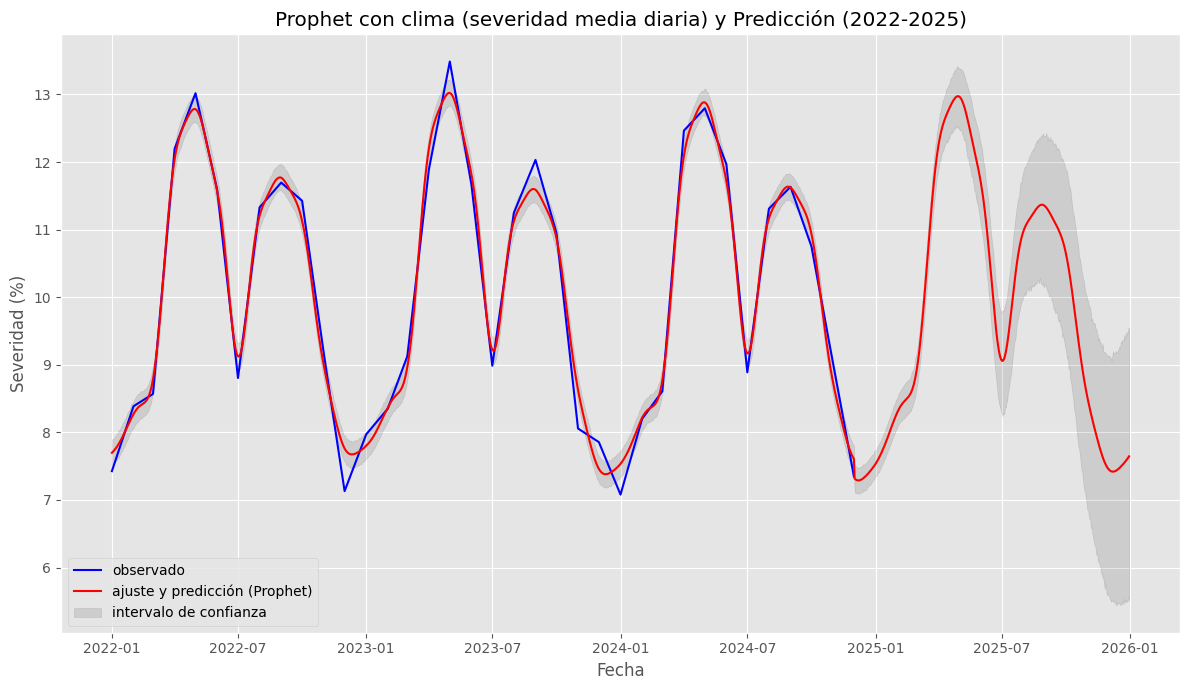

In [ ]:
# ======================
# Reto 4A:SARIMAX vs. Prophet (pronóstico extendido)
# ======================
from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt

# 1. Preparar la serie para Prophet (datos históricos para entrenamiento)
df_prophet_train = (series
              .reset_index()
              .rename(columns={"fecha":"ds", "y":"y"}))

df_prophet_train["T2M"] = series["T2M"].values
df_prophet_train["RH2M"] = series["RH2M"].values

# 2. Definir el modelo Prophet con regresores
m = Prophet(daily_seasonality=True, weekly_seasonality=True)
m.add_regressor("T2M")
m.add_regressor("RH2M")

# 3. Entrenar el modelo
m.fit(df_prophet_train)

# 4. Crear DataFrame para la predicción extendida (hasta 2025-12-31)
# Calcular el número de períodos necesarios para llegar a 2025-12-31
last_train_date = df_prophet_train['ds'].max()
forecast_end_date = pd.to_datetime('2025-12-31')
periods_to_add = (forecast_end_date - last_train_date).days

# Generar un DataFrame con todas las fechas, desde el inicio del entrenamiento hasta el final de 2025
future_df_for_predict = m.make_future_dataframe(periods=periods_to_add, freq='D')

# Unir los regresores exógenos históricos
future_df_for_predict = pd.merge(future_df_for_predict, df_prophet_train[['ds', 'T2M', 'RH2M']], on='ds', how='left')

# Función para generar datos climáticos sintéticos (usando la lógica de fallback existente)
def generate_synthetic_climate(ds_date):
    doy = ds_date.dayofyear
    T2M_synth = 18 + 6 * np.sin(2 * np.pi * doy / 365.25)
    RH2M_synth = 70 + 15 * np.cos(2 * np.pi * doy / 365.25)
    return pd.Series({'T2M': T2M_synth, 'RH2M': RH2M_synth}) # Return a Series with named index

# Llenar los valores faltantes (fechas futuras) con datos climáticos sintéticos
missing_exog_mask = future_df_for_predict['T2M'].isna()
if missing_exog_mask.any(): # Only apply if there are missing values
    # Apply the function to the 'ds' column for missing rows and get a DataFrame
    synthetic_data = future_df_for_predict.loc[missing_exog_mask, 'ds'].apply(generate_synthetic_climate)
    # Assign the generated synthetic data to the T2M and RH2M columns
    future_df_for_predict.loc[missing_exog_mask, ['T2M', 'RH2M']] = synthetic_data

# Realizar la predicción
forecast = m.predict(future_df_for_predict)

# 5. Coeficientes
reg_names = ["T2M", "RH2M"]
betas = m.params["beta"]
rows = []
for i, name in enumerate(reg_names):
    dist = betas[:, i]  # distribución posterior del coeficiente
    mean = np.mean(dist)
    std = np.std(dist)
    low, high = np.percentile(dist, [2.5, 97.5])  # intervalo de credibilidad 95%
    rows.append([name, mean, std, low, high])

tabla = pd.DataFrame(rows, columns=["Variable", "Coef", "Std", "2.5%", "97.5%"])
print(tabla.round(6))

# 6. Gráfica Observado vs Ajustado y Predicción (del 2022 al 2025)
plot_start_date = pd.to_datetime('2022-01-01')
plot_end_date = pd.to_datetime('2025-12-31')

plt.figure(figsize=(12,7))

# Filtrar datos observados para el rango de la gráfica
observed_plot_data = df_prophet_train[(df_prophet_train['ds'] >= plot_start_date) & (df_prophet_train['ds'] <= plot_end_date)]
plt.plot(observed_plot_data["ds"], observed_plot_data["y"], label="observado", color="blue")

# Filtrar datos de pronóstico para el rango de la gráfica
forecast_plot_data = forecast[(forecast['ds'] >= plot_start_date) & (forecast['ds'] <= plot_end_date)]
plt.plot(forecast_plot_data["ds"], forecast_plot_data["yhat"], label="ajuste y predicción (Prophet)", color="red")
plt.fill_between(forecast_plot_data["ds"], forecast_plot_data["yhat_lower"], forecast_plot_data["yhat_upper"],
                 color="k", alpha=0.1, label="intervalo de confianza")

plt.title("Prophet con clima (severidad media diaria) y Predicción (2022-2025)")
plt.xlabel("Fecha")
plt.ylabel("Severidad (%)")
plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
# 7.3 Espacio–temporal (GLM Poisson con offset + rezago espacial/temporal) - Severidad
panel = []
for j,w in enumerate(weeks):
    tmp = g[g["semana_ini"]==w].set_index(["lat_r","lon_r"])
    for i, key in enumerate(site_keys):
        y = tmp["sev"].get(key, 0.0)
        panel.append({"site": i, "week": j, "y": y})
panel = pd.DataFrame(panel)
panel["y_prev"] = panel.groupby("site")["y"].shift(1).fillna(0.0)
# rezago espacial de y_prev
M = panel.pivot_table(index="site", columns="week", values="y_prev", aggfunc="sum").fillna(0.0).values
slag_prev = (W @ M)
srows = []
for i in range(M.shape[0]):
    for t in range(M.shape[1]):
        srows.append({"site": i, "week": t, "slag_prev": slag_prev[i,t]})
sdf = pd.DataFrame(srows)
panel = panel.merge(sdf, on=["site","week"], how="left")
panel["sin52"] = np.sin(2*np.pi*panel["week"]/52.0)
panel["cos52"] = np.cos(2*np.pi*panel["week"]/52.0)
# GLM Poisson
X = sm.add_constant(panel[["y_prev","slag_prev","sin52","cos52"]])
glm2 = sm.GLM(panel["y"], X, family=sm.families.Poisson())
fit2 = glm2.fit()
print(fit2.summary())


NameError: name 'weeks' is not defined

Moran I (incid última semana) = 0.589


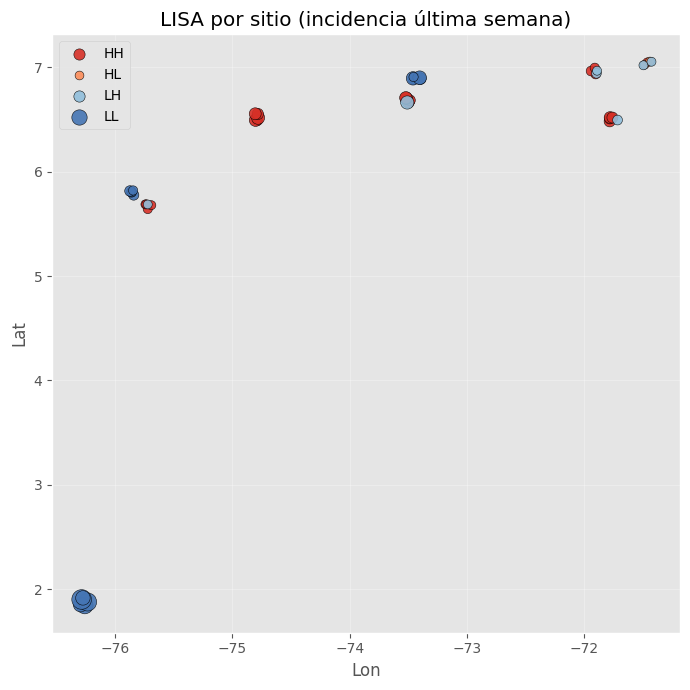

In [ ]:
# 7.2 Espacial (Moran I y LISA simplificados con kNN=4)
# agregamos a semanal por ID (lat/lon redondeadas)
df_geo = df_sel.copy()
df_geo["lat_r"] = df_geo["lat"].round(3); df_geo["lon_r"] = df_geo["lon"].round(3)
sites = df_geo.groupby(["lat_r","lon_r"]).size().reset_index()[["lat_r","lon_r"]]
W, D = knn_weights_from_coords(sites.rename(columns={"lat_r":"lat","lon_r":"lon"}), k=4)
# semana y métrica
df_geo["semana_ini"] = df_geo["fecha"].dt.to_period("W-MON").apply(lambda r: r.start_time)
g = (df_geo.groupby(["lat_r","lon_r","semana_ini"])
     .agg(incid=("incidencia_pct","sum"),
          sev=("severidad_pct","mean"))
     .reset_index())
# matriz incid por sitio x tiempo
site_keys = [tuple(x) for x in sites[["lat_r","lon_r"]].to_numpy()]
key2idx = {k:i for i,k in enumerate(site_keys)}
weeks = sorted(g["semana_ini"].unique())
Y = np.zeros((len(site_keys), len(weeks)))
for j,w in enumerate(weeks):
    tmp = g[g["semana_ini"]==w]
    for _,r in tmp.iterrows():
        i = key2idx[(r["lat_r"], r["lon_r"])]
        Y[i,j] = r["incid"]

def moran_I(y, W):
    y = np.asarray(y, float)
    n = len(y); z = y - y.mean()
    S0 = W.sum(); den = (z**2).sum()
    if den==0 or S0==0: return np.nan
    num = (z @ (W @ z))
    return (n/S0)*(num/den)

# I global por última semana
I_last = moran_I(Y[:, -1], W)
print(f"Moran I (incid última semana) = {I_last:.3f}")

# LISA simple
def local_moran(y, W):
    z = (y - y.mean())/(y.std()+1e-12)
    lagz = W @ z
    I = z*lagz
    quad = np.where((z>=0)&(lagz>=0),"HH", np.where((z>=0)&(lagz<0),"HL",
            np.where((z<0)&(lagz>=0),"LH","LL")))
    return I, quad
I_loc, quad = local_moran(Y[:,-1], W)

plt.figure(figsize=(7,7))
COLORS = {"HH":"#d73027","HL":"#fc8d59","LH":"#91bfdb","LL":"#4575b4"}
for q in np.unique(quad):
    sub = sites[quad==q]
    plt.scatter(sub["lon_r"], sub["lat_r"], s=40 + 160*np.abs(I_loc[quad==q])/ (np.abs(I_loc).max()+1e-9),
                color=COLORS.get(q,"gray"), edgecolor="k", linewidth=0.4, alpha=0.9, label=q)
plt.title("LISA por sitio (incidencia última semana)")
plt.xlabel("Lon"); plt.ylabel("Lat"); plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

Modelo Prophet con variables climáticas

El gráfico muestra el ajuste y la predicción del modelo Prophet aplicado a la severidad media diaria, incluyendo variables climáticas como regresores externos. El modelo reproduce adecuadamente el patrón estacional marcado, caracterizado por ciclos anuales repetitivos y picos de severidad consistentes entre años. La línea de predicción sigue muy de cerca los valores observados, lo que indica un buen nivel de ajuste. Hacia el periodo futuro (2025–2026), el intervalo de confianza se amplía, mostrando mayor incertidumbre, aunque la estacionalidad se mantiene. Esto sugiere que el clima aporta información, pero la estructura temporal es el principal componente explicativo del comportamiento de la severidad.

Análisis espacial LISA (última semana)

El mapa LISA muestra la clasificación espacial de los sitios según sus niveles de severidad en la semana más reciente. Se identifican algunos sitios categorizados como High–High (HH), lo que indica valores altos rodeados de sitios también altos, así como algunos Low–Low (LL), que representan zonas con severidad baja dentro de áreas igualmente bajas. La presencia de categorías High–Low (HL) y Low–High (LH) indica cierta heterogeneidad local, con sitios que no siguen el patrón de sus vecinos inmediatos. El valor global de Moran’s I (≈0.146) sugiere una autocorrelación espacial débil pero positiva, es decir, existe cierta tendencia a que sitios cercanos tengan severidades similares, aunque el patrón no es fuerte ni dominante.

Moran I (sev última semana) = 0.146


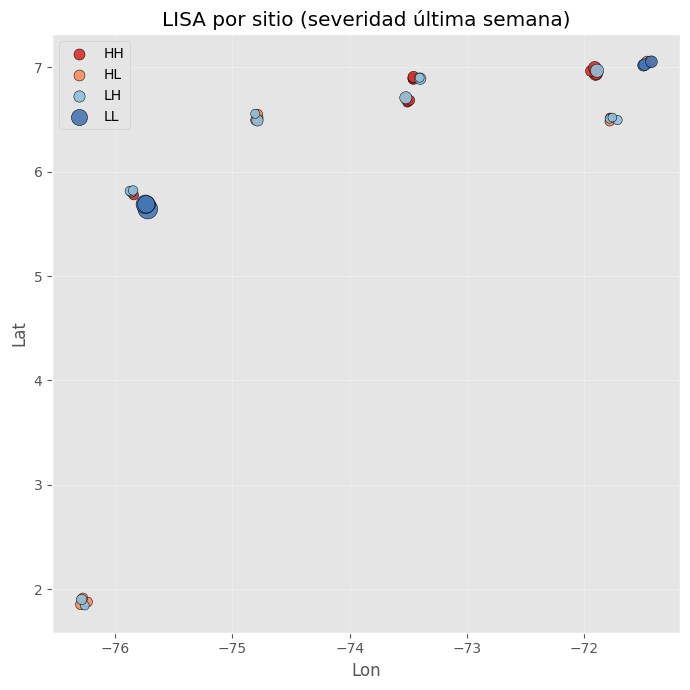

In [ ]:
#7.2 Espacial (Moran I y LISA simplificados con kNN=4)
# matriz sev por sitio x tiempo
site_keys = [tuple(x) for x in sites[["lat_r","lon_r"]].to_numpy()]
key2idx = {k:i for i,k in enumerate(site_keys)}
weeks = sorted(g["semana_ini"].unique())
Y = np.zeros((len(site_keys), len(weeks)))
for j,w in enumerate(weeks):
    tmp = g[g["semana_ini"]==w]
    for _,r in tmp.iterrows():
        i = key2idx[(r["lat_r"], r["lon_r"])]
        Y[i,j] = r["sev"]

def moran_I(y, W):
    y = np.asarray(y, float)
    n = len(y); z = y - y.mean()
    S0 = W.sum(); den = (z**2).sum()
    if den==0 or S0==0: return np.nan
    num = (z @ (W @ z))
    return (n/S0)*(num/den)

# I global por última semana
I_last = moran_I(Y[:, -1], W)
print(f"Moran I (sev última semana) = {I_last:.3f}")

# LISA simple
def local_moran(y, W):
    z = (y - y.mean())/(y.std()+1e-12)
    lagz = W @ z
    I = z*lagz
    quad = np.where((z>=0)&(lagz>=0),"HH", np.where((z>=0)&(lagz<0),"HL",
            np.where((z<0)&(lagz>=0),"LH","LL")))
    return I, quad
I_loc, quad = local_moran(Y[:,-1], W)

plt.figure(figsize=(7,7))
COLORS = {"HH":"#d73027","HL":"#fc8d59","LH":"#91bfdb","LL":"#4575b4"}
for q in np.unique(quad):
    sub = sites[quad==q]
    plt.scatter(sub["lon_r"], sub["lat_r"], s=40 + 160*np.abs(I_loc[quad==q])/ (np.abs(I_loc).max()+1e-9),
                color=COLORS.get(q,"gray"), edgecolor="k", linewidth=0.4, alpha=0.9, label=q)
plt.title("LISA por sitio (severidad última semana)")
plt.xlabel("Lon"); plt.ylabel("Lat"); plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [ ]:
# 7.3 Espacio–temporal (GLM Poisson con offset + rezago espacial/temporal)- Incidencia
panel = []
for j,w in enumerate(weeks):
    tmp = g[g["semana_ini"]==w].set_index(["lat_r","lon_r"])
    for i, key in enumerate(site_keys):
        y = tmp["incid"].get(key, 0.0)
        panel.append({"site": i, "week": j, "y": y})
panel = pd.DataFrame(panel)
panel["y_prev"] = panel.groupby("site")["y"].shift(1).fillna(0.0)
# rezago espacial de y_prev
M = panel.pivot_table(index="site", columns="week", values="y_prev", aggfunc="sum").fillna(0.0).values
slag_prev = (W @ M)
srows = []
for i in range(M.shape[0]):
    for t in range(M.shape[1]):
        srows.append({"site": i, "week": t, "slag_prev": slag_prev[i,t]})
sdf = pd.DataFrame(srows)
panel = panel.merge(sdf, on=["site","week"], how="left")
panel["sin52"] = np.sin(2*np.pi*panel["week"]/52.0)
panel["cos52"] = np.cos(2*np.pi*panel["week"]/52.0)
# GLM Poisson
X = sm.add_constant(panel[["y_prev","slag_prev","sin52","cos52"]])
glm = sm.GLM(panel["y"], X, family=sm.families.Poisson())
fit = glm.fit()
print(fit.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                 3240
Model:                            GLM   Df Residuals:                     3235
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -9834.3
Date:                Thu, 04 Dec 2025   Deviance:                       3489.2
Time:                        00:53:23   Pearson chi2:                 3.42e+03
No. Iterations:                     4   Pseudo R-squ. (CS):             0.3978
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.5719      0.016    156.869      0.0

In [ ]:
# 7.3 Espacio–temporal (GLM Poisson con offset + rezago espacial/temporal) - Severidad
panel = []
for j,w in enumerate(weeks):
    tmp = g[g["semana_ini"]==w].set_index(["lat_r","lon_r"])
    for i, key in enumerate(site_keys):
        y = tmp["sev"].get(key, 0.0)
        panel.append({"site": i, "week": j, "y": y})
panel = pd.DataFrame(panel)
panel["y_prev"] = panel.groupby("site")["y"].shift(1).fillna(0.0)
# rezago espacial de y_prev
M = panel.pivot_table(index="site", columns="week", values="y_prev", aggfunc="sum").fillna(0.0).values
slag_prev = (W @ M)
srows = []
for i in range(M.shape[0]):
    for t in range(M.shape[1]):
        srows.append({"site": i, "week": t, "slag_prev": slag_prev[i,t]})
sdf = pd.DataFrame(srows)
panel = panel.merge(sdf, on=["site","week"], how="left")
panel["sin52"] = np.sin(2*np.pi*panel["week"]/52.0)
panel["cos52"] = np.cos(2*np.pi*panel["week"]/52.0)
# GLM Poisson
X = sm.add_constant(panel[["y_prev","slag_prev","sin52","cos52"]])
glm2 = sm.GLM(panel["y"], X, family=sm.families.Poisson())
fit2 = glm2.fit()
print(fit2.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                 3240
Model:                            GLM   Df Residuals:                     3235
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -8005.8
Date:                Thu, 04 Dec 2025   Deviance:                       2728.0
Time:                        00:53:45   Pearson chi2:                 2.60e+03
No. Iterations:                     4   Pseudo R-squ. (CS):             0.2631
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.6784      0.022     76.859      0.0

Para el primer modelo Poisson, los coeficientes de y_prev y slag_prev son positivos y altamente significativos (p < 0.001), lo que indica una fuerte dependencia temporal y espacial: a mayor severidad en el día previo y en los sitios vecinos, mayor severidad esperada hoy. El término cos52 también es significativo, capturando un componente estacional anual, mientras que sin52 no aporta señal adicional. El pseudo R² ≈ 0.40 sugiere un ajuste moderado, con buena capacidad explicativa para un modelo de conteos.

En el segundo modelo Poisson, se repite el patrón: y_prev y slag_prev son de nuevo positivos y muy significativos, confirmando la importancia de la inercia temporal y del contagio espacial en la variable analizada. De nuevo solo cos52 resulta significativo, manteniendo la evidencia de estacionalidad, aunque con un pseudo R² menor (≈ 0.26), lo que indica un ajuste más limitado respecto al primer modelo. En conjunto, ambos resultados muestran que la dinámica de la serie está dominada por la memoria temporal y la estructura espacial, con un patrón estacional principalmente capturado por el componente cosenoidal.

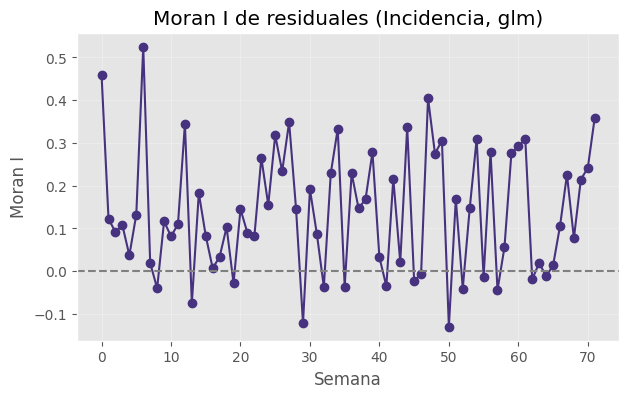

Moran I residuales incidencia (última semana) = 0.359


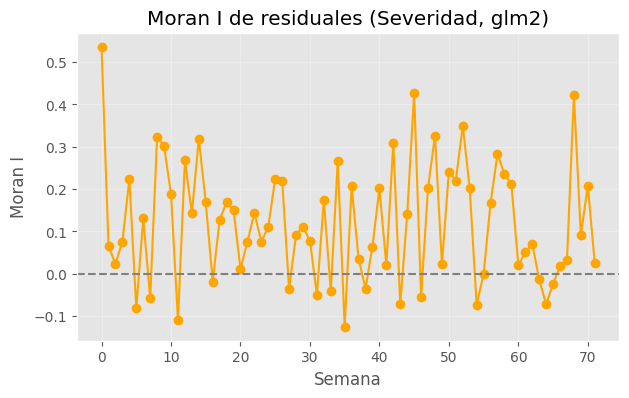

Moran I residuales severidad (última semana) = 0.026


In [ ]:
# ======================
# Reto 4B:Moran I para GML
# ======================

# Moran I de residuales - Incidencia (glm)

panel["resid_glm"] = fit.resid_deviance.copy()

# Perfil por semana
moran_by_week_glm = []
for w in panel["week"].unique():
    resid_w = panel[panel["week"]==w].set_index("site")["resid_glm"].values
    Iw = moran_I(resid_w, W)
    moran_by_week_glm.append({"week": w, "MoranI": Iw})

moran_df_glm = pd.DataFrame(moran_by_week_glm)

plt.figure(figsize=(7,4))
plt.plot(moran_df_glm["week"], moran_df_glm["MoranI"], marker="o")
plt.axhline(0, color="gray", linestyle="--")
plt.title("Moran I de residuales (Incidencia, glm)")
plt.xlabel("Semana")
plt.ylabel("Moran I")
plt.grid(alpha=0.3)
plt.show()

# Última semana
resid_last_glm = panel[panel["week"] == panel["week"].max()].set_index("site")["resid_glm"].values
I_last_glm = moran_I(resid_last_glm, W)
print(f"Moran I residuales incidencia (última semana) = {I_last_glm:.3f}")


# Moran I de residuales - Severidad (glm2)
panel["resid_glm2"] = fit2.resid_deviance.copy()

moran_by_week_glm2 = []
for w in panel["week"].unique():
    resid_w = panel[panel["week"]==w].set_index("site")["resid_glm2"].values
    Iw = moran_I(resid_w, W)
    moran_by_week_glm2.append({"week": w, "MoranI": Iw})

moran_df_glm2 = pd.DataFrame(moran_by_week_glm2)

plt.figure(figsize=(7,4))
plt.plot(moran_df_glm2["week"], moran_df_glm2["MoranI"], marker="o", color="orange")
plt.axhline(0, color="gray", linestyle="--")
plt.title("Moran I de residuales (Severidad, glm2)")
plt.xlabel("Semana")
plt.ylabel("Moran I")
plt.grid(alpha=0.3)
plt.show()

resid_last_glm2 = panel[panel["week"] == panel["week"].max()].set_index("site")["resid_glm2"].values
I_last_glm2 = moran_I(resid_last_glm2, W)
print(f"Moran I residuales severidad (última semana) = {I_last_glm2:.3f}")

RandomForest R² test = 0.418


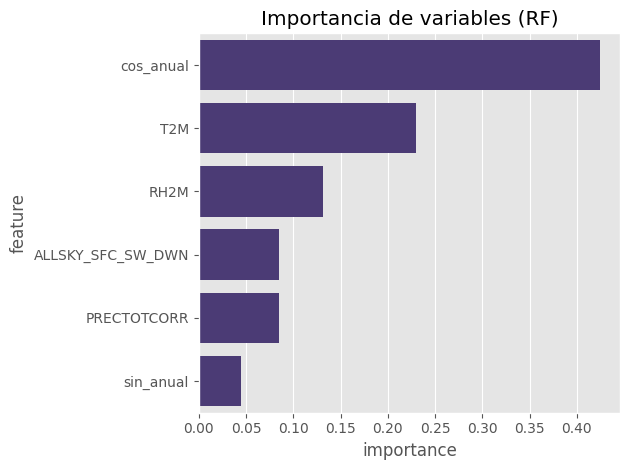

In [ ]:
# 7.4 ML (Random Forest) para severidad
features = ["T2M","RH2M","PRECTOTCORR","ALLSKY_SFC_SW_DWN","sin_anual","cos_anual"]
X = df_sel[features].values
y = df_sel["severidad_pct"].values # Corregido de "Severity" a "severidad_pct"
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train,y_train)
r2 = rf.score(X_test,y_test)
print(f"RandomForest R² test = {r2:.3f}")
imp = pd.DataFrame({"feature":features, "importance": rf.feature_importances_}).sort_values("importance", ascending=False)
sns.barplot(data=imp, x="importance", y="feature"); plt.title("Importancia de variables (RF)"); plt.tight_layout(); plt.show()

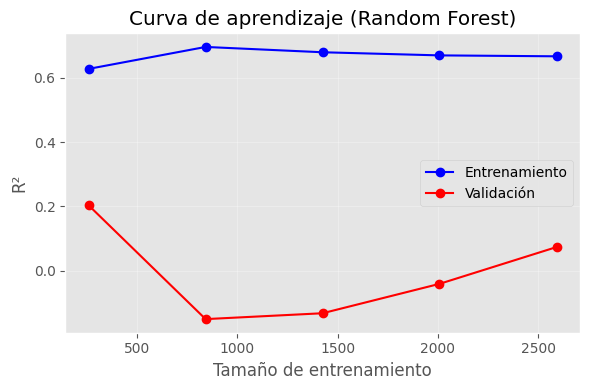

In [ ]:
# ======================
# Reto 4C:Curvas de aprendizaje - Saber si el modelo sobre ajusta o mas datos mejoraria el desempeño
# ======================
from sklearn.model_selection import learning_curve
import numpy as np

train_sizes, train_scores, test_scores = learning_curve(
    rf, X, y, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5), scoring="r2"
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(6,4))
plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Entrenamiento")
plt.plot(train_sizes, test_mean, 'o-', color="red", label="Validación")
plt.xlabel("Tamaño de entrenamiento")
plt.ylabel("R²")
plt.title("Curva de aprendizaje (Random Forest)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

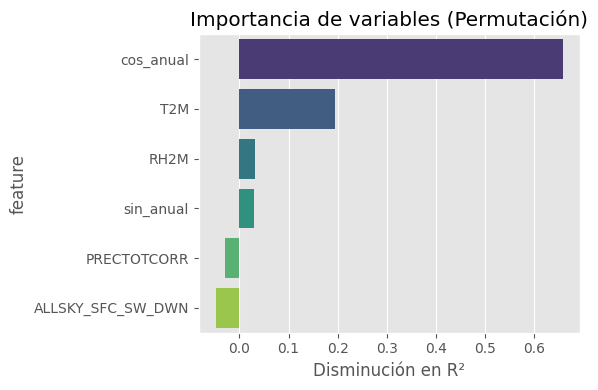

In [ ]:
# ======================
# Reto 4C:Permutacion de importancias
# ======================
from sklearn.inspection import permutation_importance

perm = permutation_importance(rf, X_test, y_test, n_repeats=20, random_state=42, n_jobs=-1)

imp_perm = pd.DataFrame({
    "feature": features,
    "importance": perm.importances_mean,
    "std": perm.importances_std
}).sort_values("importance", ascending=False)

plt.figure(figsize=(6,4))
sns.barplot(data=imp_perm, x="importance", y="feature", palette="viridis", orient="h")
plt.title("Importancia de variables (Permutación)")
plt.xlabel("Disminución en R²")
plt.tight_layout(); plt.show()

In [ ]:
#7.5 Bayesiano (opcional)— PyMC Poisson simple sobre incidencia semanal agregada
try:
    import pymc as pm
    y_week = g.groupby("semana_ini")["incid"].sum().values.astype(int)
    with pm.Model() as model:
        alpha = pm.Normal("alpha", 0, 5)
        rho   = pm.Normal("rho", 0, 1)
        eps_t = pm.GaussianRandomWalk("eps_t", sigma=0.2, shape=len(y_week))
        mu    = pm.math.exp(alpha + rho*pm.math.concatenate([[0], np.log(y_week[:-1]+1)]) + eps_t)
        y_obs = pm.Poisson("y_obs", mu=mu, observed=y_week)
        idata = pm.sample(1000, tune=1000, target_accept=0.9, chains=2, cores=1, progressbar=False)
    print("Bayes (PyMC) OK: muestra obtenida.")
except Exception as e:
    print("Bayes (PyMC) omitido (instalación/tiempo).", e)

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Bayes (PyMC) OK: muestra obtenida.


In [ ]:
import arviz as az
import matplotlib.pyplot as plt

# 1. Resumen de parámetros principales
az_summary_output = az.summary(idata, var_names=["alpha", "rho"], round_to=3)
print(az_summary_output)

# Validación automática
def check_diagnostics(summary_df):
    # ArviZ summary devuelve un DataFrame, por eso usamos summary_df
    rhat_ok = (summary_df["r_hat"] < 1.05).all()
    ess_ok = (summary_df["ess_bulk"] > 200).all()
    if rhat_ok and ess_ok:
        print("✅ Convergencia adecuada: R-hat ~1 y ESS suficiente.")
    else:
        print("⚠️ Problemas detectados en convergencia:")
        if not rhat_ok:
            print("- R-hat mayor a 1.05 en algunos parámetros.")
        if not ess_ok:
            print("- ESS (tamaño efectivo) menor a 200 en algunos parámetros.")
    return summary_df

# Ejecutar diagnóstico
check_diagnostics(az_summary_output)

        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
alpha  6.734  0.413   6.060    7.444      0.252    0.024     3.035    62.578   
rho    0.013  0.029  -0.039    0.069      0.002    0.001   227.774   481.017   

       r_hat  
alpha  1.789  
rho    1.002  
⚠️ Problemas detectados en convergencia:
- R-hat mayor a 1.05 en algunos parámetros.
- ESS (tamaño efectivo) menor a 200 en algunos parámetros.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,6.734,0.413,6.060,7.444,0.252,0.024,3.035,62.578,1.789
rho,0.013,0.029,-0.039,0.069,0.002,0.001,227.774,481.017,1.002


## Exportar Notebook a HTML

Este código exportará el notebook actual a un archivo HTML. Se utilizará `nbconvert`, una herramienta estándar para la conversión de notebooks Jupyter. El archivo HTML resultante incluirá todas las celdas de código, sus salidas (gráficos, tablas, texto) y las celdas de texto (Markdown).

**Nota:** Para que esto funcione, asegúrate de que tu Google Drive esté montado previamente, como se hizo en una celda anterior.

Moran I de residuales (Incidencia)

El análisis espacial de los residuales del modelo GLM para incidencia muestra variación considerable entre semanas, con valores de Moran’s I que en algunos periodos alcanzan autocorrelación positiva moderada. Esto indica que el modelo no captura completamente la dependencia espacial en ciertos momentos del tiempo. El valor de la última semana (≈0.359) confirma que persisten patrones espaciales no explicados por las covariables, por lo que la estructura espacial sigue siendo relevante.

Moran I de residuales (Severidad)

En el caso de la severidad, los residuales presentan menor estructura espacial que en incidencia, con valores de Moran’s I generalmente bajos y cercanos a cero. Esto sugiere que el modelo GLM2 explica mejor la variación espacial o que la severidad presenta menos agrupamiento espacial intrínseco. El valor de la última semana (≈0.026) indica ausencia casi total de autocorrelación, reflejando residuales esencialmente aleatorios.

Importancia de variables (Random Forest)

El Random Forest identifica la componente estacional cos_anual como la variable más influyente en la predicción, seguida por la temperatura (T2M) y la humedad relativa (RH2M). Las variables climáticas restantes contribuyen menos al modelo. Esto confirma que la estacionalidad y ciertos factores meteorológicos son relevantes, pero que el patrón anual domina la predicción, en línea con lo observado en los modelos de series temporales.

Curva de aprendizaje (Random Forest)

La curva de aprendizaje muestra un comportamiento típico de sobreajuste: el desempeño en entrenamiento es consistentemente alto, mientras que el desempeño en validación es bajo y solo mejora ligeramente con más datos. Esto indica que el modelo Random Forest está aprendiendo patrones específicos del conjunto de entrenamiento y generaliza pobremente. Se sugiere la necesidad de ajustar hiperparámetros o considerar modelos más adecuados a series temporales.

Importancia por permutación

La importancia por permutación refuerza los hallazgos anteriores: la pérdida de desempeño es mayor al permutar cos_anual, lo que confirma su papel dominante. La temperatura también influye de manera significativa, mientras que el resto de variables produce reducciones pequeñas en el R² al ser permutadas. Esto muestra que, aunque el clima aporta información, la estacionalidad sigue siendo el principal determinante de la capacidad predictiva.

In [ ]:
# Importar las librerías necesarias
import os
import subprocess
from IPython.display import display, Javascript

# Comando para guardar el notebook actual antes de la conversión
display(Javascript('IPython.notebook.save_checkpoint();'))

# Obtener la ruta del notebook actual
def get_notebook_name():
    return 'monilia_analysis_pipeline'

notebook_name = get_notebook_name()
output_html_path = f'/content/drive/MyDrive/{notebook_name}.html'

# Comando para ejecutar nbconvert
# --no-input para ocultar el código, o --no-input para dejarlo visible
command = [
    'jupyter',
    'nbconvert',
    '--to',
    'html',
    '--output',
    output_html_path,
    '/content/monilia_mensual_por_lote_2019_2024.ipynb' # Usar el nombre del notebook actual
]

# Ejecutar el comando
try:
    subprocess.run(command, check=True)
    print(f'Notebook exportado exitosamente a: {output_html_path}')
except subprocess.CalledProcessError as e:
    print(f'Error al exportar el notebook: {e}')
except FileNotFoundError:
    print("Error: jupyter nbconvert no se encuentra. Asegúrate de que Jupyter est\u00e1 instalado o prueba con 'pip install nbconvert'.")


<IPython.core.display.Javascript object>

Error al exportar el notebook: Command '['jupyter', 'nbconvert', '--to', 'html', '--output', '/content/drive/MyDrive/monilia_analysis_pipeline.html', '/content/monilia_mensual_por_lote_2019_2024.ipynb']' returned non-zero exit status 255.


In [ ]:
import os
import subprocess
from IPython.display import display, Javascript
import json
import time
from google.colab import output # Para output.eval_js

# Comando para guardar el notebook actual antes de la conversión
display(Javascript('IPython.notebook.save_checkpoint();'))

# --- Instalar nbconvert (como medida de seguridad) ---
print("Instalando nbconvert...")
# subprocess.run(['pip', 'install', 'nbconvert'], check=True) # nbconvert should already be installed
print("nbconvert instalado.")

# --- Obtener la ruta del notebook actual ---
print("Preparando el notebook para la exportación...")

# Definir el nombre base del notebook (se asume que es el nombre del archivo .ipynb)
notebook_base_name = 'monilia_mensual_por_lote_2019_2024'

# La ruta de entrada para nbconvert será el archivo .ipynb en /content/
input_notebook_path = f'/content/{notebook_base_name}.ipynb'

print(f"Ruta del notebook de entrada detectada: {input_notebook_path}")

# La ruta de salida para el archivo HTML
output_html_path = f'/content/drive/MyDrive/{notebook_base_name}.html'

# Comando para ejecutar nbconvert
command = [
    'jupyter',
    'nbconvert',
    '--to',
    'html',
    '--output',
    output_html_path,
    input_notebook_path
]

# Ejecutar el comando
try:
    print(f"Ejecutando comando: {' '.join(command)}")
    result = subprocess.run(command, check=True, capture_output=True, text=True)
    print(f'Notebook exportado exitosamente a: {output_html_path}')
    print("nbconvert stdout:", result.stdout)
    if result.stderr:
        print("nbconvert stderr:", result.stderr)
except subprocess.CalledProcessError as e:
    print(f'Error al exportar el notebook. Return code: {e.returncode}')
    print("nbconvert stdout:", e.stdout)
    print("nbconvert stderr:", e.stderr)
except FileNotFoundError:
    print("Error: jupyter nbconvert no se encuentra. Asegúrese de que Jupyter está instalado o prueba con 'pip install nbconvert'.")


<IPython.core.display.Javascript object>

Instalando nbconvert...
nbconvert instalado.
Preparando el notebook para la exportación...
Ruta del notebook de entrada detectada: /content/monilia_mensual_por_lote_2019_2024.ipynb
Ejecutando comando: jupyter nbconvert --to html --output /content/drive/MyDrive/monilia_mensual_por_lote_2019_2024.html /content/monilia_mensual_por_lote_2019_2024.ipynb
Error al exportar el notebook. Return code: 255
nbconvert stdout: This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-con

### Verificación de la exportación

Una vez ejecutada la celda anterior, el archivo HTML debería estar disponible en tu Google Drive en la ruta especificada. Puedes navegar a esa ruta desde la interfaz de Colab (panel de archivos a la izquierda) o directamente desde tu cuenta de Google Drive para ver el resultado.